Hey there


# Functions and PreReqs

## installations

In [162]:
# dump the junk in dev/null

! pip install hdf5storage &> /dev/null
! pip install pytorch_lightning &> /dev/null


# don't use this test utils
# it's using its own test_utils
# ! pip install test_utils

!pip uninstall torchmetrics -y &> /dev/null
!pip install torchmetrics==0.7.0 &> /dev/null


# this is not found !pip install torchvision==0.8.2
! pip install torchvision &> /dev/null

## mount drive and ch dir and path insert

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
import sys
import os
os.chdir('/content/gdrive/My Drive/HPPP/')
print(f"Current working directory: {os.getcwd()}")
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Prox_PnP')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Prox_PnP/PnP_restoration')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Prox_PnP/PnP_restoration/utils')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Prox_PnP/PnP_restoration/kernels')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Prox_PnP/PnP_restoration/Levin09.mat')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Prox_PnP/PnP_restoration/models')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Prox_PnP/PnP_restoration/GS_denoising')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Prox_PnP/PnP_restoration/GS_denoising/models')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Prox_PnP/PnP_restoration/datasets')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Provable_PnP')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Provable_PnP/utils')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Provable_PnP/model')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Provable_PnP/training')
sys.path.insert(0, '/content/gdrive/My Drive/HPPP/Provable_PnP/Pretrained_models')


Mounted at /content/gdrive
Current working directory: /content/gdrive/My Drive/HPPP


## imports

In [164]:
import numpy as np
import hdf5storage
import argparse
import cv2
import sys
import torch
import scipy.io as scio
import torch.nn as nn
import matplotlib.pyplot as plt

from PnP_restoration.utils.utils_restoration import matlab_style_gauss2D, imread_uint
from argparse import ArgumentParser
from scipy import ndimage

# I'll implement it in the small function parts since it's just a simple function
# from PnP_restoration.utils.utils_restoration import array2tensor

from PnP_restoration.utils import utils_sr

In [165]:
! pwd

/content/gdrive/My Drive/HPPP


## Parsers

In [166]:
parser = argparse.ArgumentParser()
parser.add_argument('--task', type=str, default='Gaussian-deblurring', help='image deblurring or super-resolution')###Gaussian-deblurring; Uniform-deblurring; Super-resolution
parser.add_argument('--scale', type=int, default=1, help='image scale')
parser.add_argument('--ycbcr', type=str, choices=['True', 'False'], default='False', help='Enable YCbCr mode')
# we changed it since CRED sucks
# parser.add_argument('--algo', type=str, default='CRED', help='algorithms')
parser.add_argument('--algo', type=str, default='RED', help='algorithms')
parser.add_argument('--dataset', type=str, default='set12', help='algorithms')
parser.add_argument('--noise_level', type=float, default=2.55, help='noise level of image')
args = parser.parse_args([]) # Pass an empty list to parse_args() to ignore kernel arguments

## Functions

### PreReqFunctions

In [167]:
def initialize_prox(img, degradation_mode, degradation, sf, device):
    if degradation_mode == 'deblurring':
        k = degradation
        k_tensor = array2tensor(np.expand_dims(k, 2)).double().to(device)
        # changed it since we didn't have pre_calculate_prox2 and instead we had pre_calculate_prox (and we changed the file utils_sr)!!
        # FB, FBC, F2B, FBFy = utils_sr.pre_calculate_prox2(img, k_tensor, sf)
        FB, FBC, F2B, FBFy = utils_sr.pre_calculate_prox(img, k_tensor, sf)
        return FB, FBC, F2B, FBFy, k_tensor
    elif degradation_mode == 'SR':
        k = degradation
        k_tensor = array2tensor(np.expand_dims(k, 2)).double().to(device)
        # changed it since we didn't have pre_calculate_prox2 and instead we had pre_calculate_prox (and we changed the file utils_sr)!!
        # FB, FBC, F2B, FBFy = utils_sr.pre_calculate_prox2(img,k_tensor, sf)
        FB, FBC, F2B, FBFy = utils_sr.pre_calculate_prox(img,k_tensor, sf)
        return FB, FBC, F2B, FBFy, k_tensor
    elif degradation_mode == 'inpainting':
        M = array2tensor(degradation).double().to(device)
        My = M*img
        return My
    else:
        print('degradation mode not treated')


In [168]:
def calulate_data_term(k_tensor,degradation_mode, sf,y,img):
        '''
        Calculation of the data term value f(y)
        :param y: Point where to evaluate F
        :param img: Degraded image
        :return: f(y)
        '''
#         k_tensor = array2tensor(np.expand_dims(k, 2)).double().to(device)
        if degradation_mode == 'deblurring':
            deg_y = utils_sr.imfilter(y.double(), k_tensor[0].double().flip(1).flip(2).expand(3, -1, -1, -1))
            f = 0.5 * torch.norm(img - deg_y, p=2) ** 2
        elif degradation_mode == 'SR':
            deg_y = utils_sr.imfilter(y.double(), k_tensor[0].double().flip(1).flip(2).expand(3, -1, -1, -1))
            deg_y = deg_y[..., 0::sf, 0::sf]
            f = 0.5 * torch.norm(img - deg_y, p=2) ** 2
#         elif degradation_mode == 'inpainting':
#             deg_y = M * y.double()
#             f = 0.5 * torch.norm(img - deg_y, p=2) ** 2
        else:
            print('degradation not implemented')
        return f


In [169]:
def calulate_gray_data_term(k_tensor,degradation_mode, sf,y,img):###适合灰度图像
        '''
        Calculation of the data term value f(y)
        :param y: Point where to evaluate F
        :param img: Degraded image
        :return: f(y)
        '''
#         k_tensor = array2tensor(np.expand_dims(k, 2)).double().to(device)
        if degradation_mode == 'deblurring':
            deg_y = utils_sr.imfilter(y.double(), k_tensor)
            f = 0.5 * torch.norm(img - deg_y, p=2) ** 2
        elif degradation_mode == 'SR':
            deg_y = utils_sr.imfilter(y.double(), k_tensor)
            deg_y = deg_y[..., 0::sf, 0::sf]
            f = 0.5 * torch.norm(img - deg_y, p=2) ** 2
#         elif degradation_mode == 'inpainting':
#             deg_y = M * y.double()
#             f = 0.5 * torch.norm(img - deg_y, p=2) ** 2
        else:
            print('degradation not implemented')
        return f


In [170]:
def rgb2ycbcr(img, only_y=True):
    '''same as matlab rgb2ycbcr
    only_y: only return Y channel
    Input:
        uint8, [0, 255]
        float, [0, 1]
    '''
    in_img_type = img.dtype
    img.astype(np.float32)
    if in_img_type != np.uint8:
        img *= 255.
    # convert
    if only_y:
        rlt = np.dot(img, [65.481, 128.553, 24.966]) / 255.0 + 16.0
    else:
        rlt = np.matmul(img, [[65.481, -37.797, 112.0], [128.553, -74.203, -93.786],
                              [24.966, 112.0, -18.214]]) / 255.0 + [16, 128, 128]
    if in_img_type == np.uint8:
        rlt = rlt.round()
    else:
        rlt /= 255.
    return rlt.astype(in_img_type)


In [171]:
def ycbcr2rgb(img):
    '''same as matlab ycbcr2rgb
    Input:
        uint8, [0, 255]
        float, [0, 1]
    '''
    in_img_type = img.dtype
    img.astype(np.float32)
    if in_img_type != np.uint8:
        img *= 255.
    # convert
    rlt = np.matmul(img, [[0.00456621, 0.00456621, 0.00456621], [0, -0.00153632, 0.00791071],
                          [0.00625893, -0.00318811, 0]]) * 255.0 + [-222.921, 135.576, -276.836]
    rlt = np.clip(rlt, 0, 255)
    if in_img_type == np.uint8:
        rlt = rlt.round()
    else:
        rlt /= 255.
    return rlt.astype(in_img_type)


### small functions

In [172]:
def single2uint(img):
    return np.uint8(img*255.)

def tensor2uint(img):
    img = img.data.squeeze().float().clamp_(0, 1).cpu().numpy()
    if img.ndim == 3:
        img = np.transpose(img, (1, 2, 0))
    return np.uint8((img*255.0).round())

def tensor2uint2(img):
    img = img.data.squeeze().float().cpu().numpy()
    img = norm_proj(img)
    if img.ndim == 3:
        img = np.transpose(img, (1, 2, 0))
    return np.uint8((img*255.0).round())

def tensor2float(img):
    img = img.data.squeeze().float().clamp_(0, 1).cpu().numpy()
    if img.ndim == 3:
        img = np.transpose(img, (1, 2, 0))
    return img

def tensor2float2(img):
    img = img.data.squeeze().float().cpu().numpy()
    img = norm_proj(img)
    if img.ndim == 3:
        img = np.transpose(img, (1, 2, 0))
    return img

def calculate_psnr(img1, img2, border=0):
    # img1 and img2 have range [0, 255]
    if not img1.shape == img2.shape:
        raise ValueError('Input images must have the same dimensions.')
    h, w = img1.shape[:2]
    img1 = img1[border:h-border, border:w-border]
    img2 = img2[border:h-border, border:w-border]

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2)**2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 /np.sqrt(mse))

def calculate_grad(img, degradation_mode, FB, FBC,FBFy,sf=1):
    if degradation_mode == 'deblurring':
        grad = utils_sr.grad_solution(img.double(), FB, FBC, FBFy, 1)
    if degradation_mode == 'SR' :
        grad = utils_sr.grad_solution(img.double(), FB, FBC, FBFy, sf)
    return grad

def mkdir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def norm_proj(x):
    x = (x-np.min(x))/(np.max(x)-np.min(x))
    return x

def imsave(img, img_path):
    if img.ndim == 3:
        img = img[:, :, [2, 1, 0]]
    cv2.imwrite(img_path, img)


In [173]:
def numpy_degradation(x, k, sf=3):
    ''' blur + downsampling
    Args:
        x: HxWxC image, [0, 1]/[0, 255]
        k: hxw, double, positive
        sf: down-scale factor
    Return:
        downsampled LR image
    '''
    x = ndimage.filters.convolve(x, np.expand_dims(k, axis=2), mode='wrap')
    st = 0
    return x[st::sf, st::sf, ...]


In [174]:
def array2tensor(img):
    '''
    permutes to bring the channel dimension to the first and unsqueezes to put it in the batch dimension
    '''
    return torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)

In [175]:
def Projection_On_L2_Ball(x, y, radius):
    # x: point to project
    # y: center of the ball
    # radius: radius of the ball


    # we change the y to have 5 dimension
    y_zeros = torch.zeros_like(y.unsqueeze(-1))
    y = torch.cat((y.unsqueeze(-1), y_zeros), dim=-1)
    print('##########yShape#############')
    print(y.shape)

    if torch.norm(x-y, p=2) > radius:
        Px = y + (x-y)/torch.norm(x-y, p=2)*radius
    else:
        Px = x
    return Px


In [176]:
def Landweber_operator(x, y, FB, FBC, delta, lambda_k=1, sf=1):
    ###Lx = x+||T(Ax)-Ax||^2/(||A*(T(Ax)-Ax)||^2) A*(T(Ax)-Ax)
    ###alpha: relaxed parameter (0,1]
    ###Ax####

    # we changed it
    # FBFx = FB.mul(torch.fft.fftn(x, dim=(-2,-1)))
    FBFx = FB.mul(torch.view_as_real(torch.fft.fftn(x, dim=(-2,-1))))
    # we changed it
    # AFx = utils_sr.downsample(torch.fft.ifftn(FBFx, dim=(-2,-1)),sf=sf)
    AFx = utils_sr.downsample(torch.fft.ifftn(FBFx, dim=(-2,-1)),sf=sf)
    # AFx = torch.real(AFx)
    ####T(Ax)####
    TAx = Projection_On_L2_Ball(AFx, y, delta)
    TAx_norm = torch.norm(TAx-AFx, p=2)**2
    ####A*(T(Ax)-Ax)####
    r = TAx - AFx
    STr = utils_sr.upsample(r, sf=sf)
    FBCSTr = FBC.mul(torch.fft.fftn(STr, dim=(-2,-1)))
    AstarFBCSTr = torch.real(torch.fft.ifftn(FBCSTr, dim=(-2,-1)))
    AstarFBCSTr_norm = torch.norm(AstarFBCSTr, p=2)**2
    if torch.norm(AFx-y, p=2) > delta:
        Lx = x +lambda_k* TAx_norm/AstarFBCSTr_norm*AstarFBCSTr
    else:
        Lx = x
    return Lx


In [177]:
def initialize_cuda_gray_denoiser(device):
    '''
    Initialize the denoiser model with the given pretrained ckpt
    '''
    sys.path.append('./ProxPnP/GS_denoising/')
    # Fixed relative import to absolute import
    # from .lightning_GSDRUNet import GradMatch
    from Prox_PnP.GS_denoising.lightning_denoiser import GradMatch

    parser2 = ArgumentParser(prog='utils_restoration.py')
    parser2 = GradMatch.add_model_specific_args(parser2)
    parser2 = GradMatch.add_optim_specific_args(parser2)
    hparams = parser2.parse_known_args()[0]
    hparams.act_mode = 'E'
    hparams.grayscale = True
    denoiser_model = GradMatch(hparams)
    # print(self.hparams.pretrained_checkpoint)换成单通道的模型

    # changed it! (:
    # hparams.pretrained_checkpoint = './Prox_PnP/GS_denoising/ckpts/GSDRUNet_grayscale.ckpt'
    # hparams.pretrained_checkpoint = './Prox_PnP/GS_denoising/ckpts/GS_DRUNet.ckpt'
    hparams.pretrained_checkpoint = './Prox_PnP/GS_denoising/ckpts/GSDRUNet.ckpt'

    # we changed it (:
    # checkpoint = torch.load(hparams.pretrained_checkpoint, map_location=device)
    checkpoint = torch.load(hparams.pretrained_checkpoint, map_location=device, weights_only= False)
    # we changed it due to the KeyError
    denoiser_model.load_state_dict(checkpoint['state_dict'],strict=False)

    denoiser_model.load_state_dict(checkpoint,strict=False)

    denoiser_model.eval()
    for i, v in denoiser_model.named_parameters():
        v.requires_grad = False
    denoiser_model = denoiser_model.to(device)
    return denoiser_model

In [178]:
def load_model(model_type, sigma, device):
    os.chdir('/content/gdrive/My Drive/HPPP')
    path = "./Provable_PnP/Pretrained_models/" + model_type + "_noise" + str(sigma) + ".pth"
    if model_type == "DnCNN":
        from Provable_PnP.model.models import DnCNN
        net = DnCNN(channels=1, num_of_layers=17)
        model = nn.DataParallel(net).cuda()
    elif model_type == "SimpleCNN":
        from Provable_PnP.model.SimpleCNN_models import DnCNN
        model = DnCNN(1, num_of_layers = 4, lip = 0.0, no_bn = True).cuda()
    elif model_type == "RealSN_DnCNN":
        from Provable_PnP.model.realSN_models import DnCNN
        net = DnCNN(channels=1, num_of_layers=17)
        model = nn.DataParallel(net).cuda()
    elif model_type == "FNE_DnCNN":
        from Provable_PnP.model.full_realsn_models import FNE_DnCNN as DnCNN
        net = DnCNN(channels=1, num_of_layers=17).cuda()
        path = './Pretrained_models2/FNE_DnCNN_5/best_model.pth'
        # path ='./Pretrained_models2/FNE_DnCNN/epoch46_noise5_PSNR34.54_SSIM0.89.pth'
        model = net.cuda(device.index)
        # model = nn.DataParallel(net).cuda()
    elif model_type == "RealSN_SimpleCNN":
        from Provable_PnP.model.SimpleCNN_models import DnCNN
        model = DnCNN(1, num_of_layers = 4, lip = 1.0, no_bn = True).cuda()
    elif model_type == "MMO":
        from training.spc_models import simple_DnCNN
        model = simple_DnCNN(n_ch_in=1, n_ch_out=1, n_ch=64, nl_type='softplus', depth=20, bn=False).cuda()
        path ='./Pretrained_models2/SPCnet_sn_iters_10_0.8/best_model.pth'
        # path = './Pretrained_models2/SPCnet_MMO/epoch6_noise[0, 25]_PSNR34.01_SSIM0.89_128hc.pth'
    else:
        from Provable_PnP.model.realSN_models import DnCNN
        net = DnCNN(channels=1, num_of_layers=17)
        model = nn.DataParallel(net).cuda()

    model.load_state_dict(torch.load(path))
    model.eval()
    return model


In [179]:
##################################算法部分##################################
def SCFP_LFP_PnP(x0,y, k_tensor, FB, FBC, f, opt):
    K = opt['K']
    alpha = opt['alpha']
    beta = opt['beta']
    sigma = opt['sigma']
    sigma_norm = opt['sigma_norm']
    mu_0 = opt['mu_0']
    Sf = opt['sf']
    model_type = opt['model_type']
    model_name = opt['model_name']
    obj_fun = np.zeros(K)
    residual = torch.zeros(K)
    for i in range(K):
        x = x0
        Lx = Landweber_operator(x, y, FB, FBC, sigma_norm, alpha, sf=Sf)
        if model_type != 'FPNet':
            f_est = Lx
            mintmp = torch.min(f_est)
            maxtmp = torch.max(f_est)
            xtilde = (f_est - mintmp) / (maxtmp - mintmp)
            scale_range = 1.0 + sigma/255.0/2.0
            scale_shift = (1 - scale_range) / 2.0
            xtilde = xtilde * scale_range + scale_shift
            r = f(xtilde.float())
            z= xtilde - r
            z= (z - scale_shift) / scale_range
            z = z * (maxtmp - mintmp) + mintmp
            z = (1-beta)*f_est+beta*z
        else:
            if 'dncnn' in model_name:
                z = f(Lx.clamp_(0, 1).float())
                z = (1-beta)*Lx+beta*z
        x0 = z
    return x0


### Different Algorithms

In [180]:
def SAM_PRO_v2(x0,y, k_tensor, degradation_mode, FB, FBC, FBFy, f, opt):
    K = opt['K']
    alpha = opt['alpha']
    beta = opt['beta']
    sigma = opt['sigma']
    mu_0 = opt['mu_0']
    Sf = opt['sf']
    obj_fun = np.zeros(K)
    residual = torch.zeros(K)
    for i in range(K):
        x = x0
        mu_k = mu_0*(i+1)**(-1.0)
        mu = mu_k if mu_k<1 else 1
        f_est = x
        mintmp = torch.min(f_est)
        maxtmp = torch.max(f_est)
        xtilde = (f_est - mintmp) / (maxtmp - mintmp)
        scale_range = 1.0 + sigma/255.0/2.0
        scale_shift = (1 - scale_range) / 2.0
        xtilde = xtilde * scale_range + scale_shift
        r = f(xtilde.float())
        z= xtilde - r
        z= (z - scale_shift) / scale_range
        z = z * (maxtmp - mintmp) + mintmp
        z = (1-beta)*f_est+beta*z
        grad =  calculate_grad(z, degradation_mode, FB, FBC, FBFy, sf=Sf)
        v_est = z - mu*grad/sigma
        w = v_est
        residual[i] = torch.norm(w-x0, p=2)
        x0 = w
        obj_fun[i] = calulate_data_term(k_tensor,degradation_mode, Sf,x0,y).float().cpu().numpy()
    return x0, obj_fun, residual.float().cpu().numpy()


In [181]:
def RED(x0,y, k_tensor, degradation_mode, FB, FBC, FBFy, f, opt):
    K = opt['K']
    lambdaa = opt['lambda']
    sigma = opt['sigma']
    Sf = opt['sf']
    obj_fun = np.zeros(K)
    residual = torch.zeros(K)
    mu = opt['alpha']####### 0.1 for parrots(sacle =3, super-resolution); 1 for butterfly(sigma=8, uniform PSF)
    PSNR = []
    for i in range(K):
        # Assuming x_est is available from the last iteration of the main loop
        print(x0)

        plt.figure(figsize=(8, 8))
        plt.imshow(tensor2uint(x0), cmap = 'gray')
        plt.axis('off')
        plt.show()

        x = x0
        psnr = calculate_psnr(tensor2uint(x), opt['gt'])
        PSNR.append(psnr)
        obj_fun[i] = 1/sigma**2*calulate_gray_data_term(k_tensor,degradation_mode, Sf,x0,y).float().cpu().numpy()
        grad1 =  calculate_grad(x, degradation_mode, FB, FBC, FBFy, sf=Sf)/sigma
        grad2 =  f(x.float())
        v_est = x - mu*(grad1/sigma**2+lambdaa*grad2)
        w = v_est
        residual[i] = torch.norm(w-x0, p=2)
        x0 = w
    return x0, obj_fun, residual.float().cpu().numpy(), PSNR


In [182]:
def REDPRO(x0,y, k_tensor, degradation_mode, FB, FBC, FBFy, f, opt):
    K = opt['K']
    alpha = opt['alpha']
    beta = opt['beta']
    sigma = opt['sigma']
    Sf = opt['sf']
    obj_fun = np.zeros(K)
    residual = torch.zeros(K)
    PSNR = []
    for i in range(K):
        x = x0
        psnr = calculate_psnr(tensor2uint(x), opt['gt'])
        PSNR.append(psnr)
        obj_fun[i] = 1/sigma**2*calulate_gray_data_term(k_tensor,degradation_mode, Sf,x0,y).float().cpu().numpy()
        mu =alpha*(i+1)**(-0.1)################# 2 for parrots(sacle =3, super-resolution); 4 for butterfly(sigma=8, uniform PSF)
        grad1 =  calculate_grad(x, degradation_mode, FB, FBC, FBFy, sf=Sf)
        f_est = x - mu*grad1/sigma**2
        v_est = beta*(f_est-f(f_est.float()))+(1-beta)*f_est
        w = v_est
        residual[i] = torch.norm(w-x0, p=2)
        x0 = w
    return x0, obj_fun, residual.float().cpu().numpy(), PSNR


In [183]:
def PnP_FBS(x0,y, k_tensor, degradation_mode, FB, FBC, FBFy, f, opt):
    K = opt['K']
    beta = opt['beta']
    sigma = opt['sigma']
    Sf = opt['sf']
    obj_fun = np.zeros(K)
    residual = torch.zeros(K)
    mu0 = 4
    PSNR = []
    for i in range(K):
        x = x0
        psnr = calculate_psnr(tensor2uint(x), opt['gt'])
        PSNR.append(psnr)
        obj_fun[i] = 1/sigma**2*calulate_gray_data_term(k_tensor,degradation_mode, Sf,x0,y).float().cpu().numpy()
        mu = mu0################# 2 for parrots(sacle =3, super-resolution); 4 for butterfly(sigma=8, uniform PSF)
        grad1 =  calculate_grad(x, degradation_mode, FB, FBC, FBFy, sf=Sf)
        f_est = x - mu*grad1/sigma**2
        v_est = beta*(f_est-f(f_est.float()))+(1-beta)*x
        w = v_est
        residual[i] = torch.norm(w-x0, p=2)
        x0 = w
        x_square = torch.norm(x0, p=2)**2
    return x0, obj_fun, residual.float().cpu().numpy(), PSNR



In [184]:
def SAM_PRO_v1(x0,y, k_tensor, degradation_mode, FB, FBC, FBFy, f, opt):
    K = opt['K']
    alpha = opt['alpha']
    beta = opt['beta']
    sigma = opt['sigma']
    mu_0 = opt['mu_0']
    Sf = opt['sf']
    obj_fun = np.zeros(K)
    residual = torch.zeros(K)
    for i in range(K):
        x = x0
        mu_k = mu_0*(i+1)**(-1.0)
        mu = mu_k if mu_k<1 else 1
        f_est = x
        mintmp = torch.min(f_est)
        maxtmp = torch.max(f_est)
        xtilde = (f_est - mintmp) / (maxtmp - mintmp)
        scale_range = 1.0 + sigma/255.0/2.0
        scale_shift = (1 - scale_range) / 2.0
        xtilde = xtilde * scale_range + scale_shift
        r = f(xtilde.float())
        z= xtilde - r
        z= (z - scale_shift) / scale_range
        z = z * (maxtmp - mintmp) + mintmp
        z = (1-beta)*f_est+beta*z
        grad =  calculate_grad(f_est, degradation_mode, FB, FBC, FBFy, sf=Sf)
        v_est = f_est - alpha*grad/sigma
        w = (1-mu)*z+mu*v_est
        residual[i] = torch.norm(w-x0, p=2)
        x0 = w
        obj_fun[i] = calulate_data_term(k_tensor,degradation_mode, Sf,x0,y).float().cpu().numpy()
    return x0, obj_fun, residual.float().cpu().numpy()


In [185]:
def GraRED_GS_HP3(x0, y0, xa, ya, y, k_tensor, degradation_mode, FB, FBC, F2B, FBFy, f, opt,device):
    K = opt['K']
    lambdaa = opt['lambda']
    tau = opt['tau']
    s = opt['s']
    Sf = opt['sf']
    q = opt['q']
    sigma_denoiser = opt['sigma_denoiser']
    anchor_type = opt['anchor_type']
    if anchor_type == 'initialization':
        xa = x0
        # ya = 0* y0
    elif anchor_type == 'denoising':
        xa = x0-f(x0.float())
        ya = xa
        # ya = 0* y0
    x = x0
    y = y0
    obj_fun = np.zeros(K)
    residual = torch.zeros(K)
    alpha = torch.tensor(1/lambdaa).float().repeat(1, 1, 1, 1).to(device)
    for i in range(K):
        mu_k = 1/(i%q+2) if anchor_type == 'restart' else 1/(i+2)
        # mu_k = min(2/(i+1), 1)
        # mu_k = 1 /(i+10)
        x_old = x
        y_old = y
        xa = x if i%q == 0 and anchor_type == 'restart' else xa
        ya = y if i%q == 0 and anchor_type == 'restart' else ya
        d = utils_sr.prox_solution(x_old-tau*y_old, FB, FBC, F2B, FBFy, alpha, 1)
        x = mu_k*xa+(1-mu_k)*d
        f_est = y_old + s*(2*d-x_old)
        torch.set_grad_enabled(True)
        #Dg, N, g
        Dg, N, g = f.calculate_grad(f_est.float(), sigma_denoiser / 255.)
        torch.set_grad_enabled(False)
        Dg = Dg.detach()
        y = mu_k*ya+(1-mu_k)*Dg#####Dg是残差
        w = x
        residual[i] = torch.norm(w-x0, p=2)
        x0 = w
        x_square = torch.norm(x0, p=2)**2
        obj_fun[i] = calulate_data_term(k_tensor,degradation_mode, Sf,x0,y).float().cpu().numpy()/x_square.float().cpu().numpy()
    return x0, obj_fun, residual.float().cpu().numpy()


In [186]:
def PLM(x0,y, k_tensor, degradation_mode, FB, FBC, f, opt):
    K = opt['K']
    alpha = opt['alpha']
    beta = opt['beta']
    sigma = opt['sigma']
    sigma_norm = opt['sigma_norm']
    Sf = opt['sf']
    obj_fun = np.zeros(K)
    PSNR = []
    for i in range(K):
        x = x0
        psnr = calculate_psnr(tensor2uint(x), opt['gt'])
        PSNR.append(psnr)
        obj_fun[i] = 1/sigma**2*calulate_gray_data_term(k_tensor,degradation_mode, Sf,x0,y).float().cpu().numpy()
        print('####inPLM##########')
        print(x.shape)
        Lx = Landweber_operator(x, y, FB, FBC, sigma_norm, lambda_k=alpha, sf=Sf)
        z = (1-beta)*Lx+beta*(Lx-f(Lx.float()))
        x0 = z
    return x0, obj_fun, PSNR


In [187]:
def CRED_ADMM(x0,y, k_tensor, degradation_mode, FB, F2B, FBC, f, opt):
    K = opt['K']
    beta = opt['beta']
    sigma = opt['sigma']
    sigma_norm = opt['sigma_norm']
    Sf = opt['sf']
    obj_fun = np.zeros(K)
    t0 = x0
    r0 = y - utils_sr.imfilter(x0.double(), k_tensor)
    Lambda_r = torch.zeros_like(x0)
    Lambda_t = torch.zeros_like(x0)
    # x = x0.clone()
    gamma = 1.01
    Beta_r =1
    Beta_t =1
    # alpha = torch.tensor(1/20).float().repeat(1, 1, 1, 1).cuda()
    for i in range(K):
        y_tilde = y+r0-Lambda_r/Beta_r
        x_bar = t0 - Lambda_t/Beta_t
        STy_tilde = utils_sr.upsample(y_tilde, sf=Sf)
        print('#####################################shapeMismatch#################')
        print(FBC.shape)
        print(torch.view_as_real(torch.fft.fftn(STy_tilde, dim=(-2, -1))).shape)
        print('#####################################shapeMismatch#################')

        # we changed it for the dimention mismatch
        # FBFy_tilde = FBC*torch.fft.fftn(STy_tilde, dim=(-2, -1))
        FBFy_tilde = FBC*torch.view_as_real(torch.fft.fftn(STy_tilde, dim=(-2, -1)))
        obj_fun = 1/sigma**2*calulate_gray_data_term(k_tensor,degradation_mode, Sf,x0,y).float().cpu().numpy()
        alpha =Beta_t/Beta_r
        x = utils_sr.prox_solution(x_bar, FB, FBC, F2B, FBFy_tilde, alpha, Sf)
        print('###########imfilterCalledInMainNotebook#########')
        deg_x = utils_sr.imfilter(x.double(), k_tensor)##Ax
        print('###########imfilterCalledOverInMainNotebook#########')
        denoise_t = beta*(t0-f(t0.float()))+(1-beta)*t0
        t0 = 1/(1+Beta_t)*denoise_t+Beta_t/(1+Beta_t)*(x+Lambda_t/Beta_t)
        r0 = Projection_On_L2_Ball(deg_x-y+Lambda_r/Beta_r, 0, sigma_norm)
        Lambda_r +=  Beta_r*(-r0+deg_x-y)###艹艹艹,bug调了很久，要加负号
        Lambda_t +=  Beta_t*(-t0+x)
        Beta_r *= gamma
        Beta_t *= gamma
    return x,obj_fun


In [188]:
def GraRED_HP3(x0, y0, xa, ya, y, k_tensor, degradation_mode, FB, FBC, F2B, FBFy, f, opt):
    K = opt['K']
    lambdaa = opt['lambda']
    tau = opt['tau']
    s = opt['s']
    Sf = opt['sf']
    q = opt['q']
    anchor_type = opt['anchor_type']
    if anchor_type == 'initialization':
        xa = x0
        # ya = 0* y0
    elif anchor_type == 'denoising':
        xa = x0-f(x0.float())
        ya = xa
        # ya = 0* y0
    x = x0
    y = y0
    obj_fun = np.zeros(K)
    residual = torch.zeros(K)
    alpha = torch.tensor(1/lambdaa).float().repeat(1, 1, 1, 1).to(device)
    for i in range(K):
        mu_k = 1/(i%q+10) if anchor_type == 'restart' else 1/(i+10)
        # mu_k = min(2/(i+1), 1)
        # mu_k = 1 /(i+10)
        x_old = x
        y_old = y
        xa = x if i%q == 0 and anchor_type == 'restart' else xa
        ya = y if i%q == 0 and anchor_type == 'restart' else ya
        d =  utils_sr.prox_solution(x_old-tau*y_old, FB, FBC, F2B, FBFy, alpha, 1)
        x = mu_k*xa+(1-mu_k)*d
        f_est = y_old + s*(2*d-x_old)
        y = mu_k*ya+(1-mu_k)*(f(f_est.float()))#####fest-z是残差
        w = x
        residual[i] = torch.norm(w-x0, p=2)
        x0 = w
        x_square = torch.norm(x0, p=2)**2
        obj_fun[i] = calulate_data_term(k_tensor,degradation_mode, Sf,x0,y).float().cpu().numpy()/x_square.float().cpu().numpy()
    return x0, obj_fun, residual.float().cpu().numpy()


In [189]:
! pwd

/content/gdrive/My Drive/HPPP


# Main

ycbcr_mode:  False
algorithm:  RED
task:  Gaussian-deblurring
noise_level:  2.55
##########################before#initialize#cuda#gray#denoiser
##########################after#initialize#cuda#gray#denoiser
noise norm:  3.92938926552206
algorithm :  RED
tensor([[[[0.3253, 0.2854, 0.3041,  ..., 0.4475, 0.4103, 0.3518],
          [0.3827, 0.3671, 0.3915,  ..., 0.6082, 0.5397, 0.4767],
          [0.5214, 0.4810, 0.5337,  ..., 0.7442, 0.6941, 0.5956],
          ...,
          [0.2795, 0.2750, 0.2441,  ..., 0.3252, 0.3096, 0.3064],
          [0.2632, 0.2473, 0.2377,  ..., 0.3236, 0.3287, 0.2899],
          [0.2719, 0.2452, 0.2355,  ..., 0.3600, 0.3212, 0.3113]]]],
       device='cuda:0')


/tmp/ipykernel_3404/918805520.py:61: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  blur_im = ndimage.filters.convolve(input_im, np.expand_dims(k, axis=2), mode='wrap')


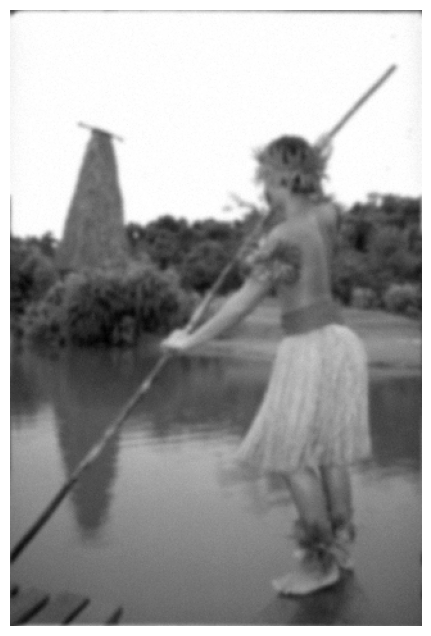

tensor([[[[ 11.5829+41.1015j,  11.1286+41.1220j,   9.9997+41.1861j,
            ...,   8.5198+41.2974j,  10.1053+41.1861j,
            11.1950+41.1220j],
          [-37.9440+16.0298j, -38.5136+16.0589j, -40.0183+16.1418j,
            ..., -41.9659+16.2634j, -39.8704+16.1418j,
           -38.4041+16.0589j],
          [-54.7632-0.5372j, -55.3829-0.4940j, -56.9350-0.3886j,
            ..., -58.9914-0.2716j, -56.7756-0.3886j,
           -55.2684-0.4940j],
          ...,
          [-21.0526-1.3753j, -21.1159-1.3820j, -21.2873-1.3972j,
            ..., -21.3551-1.4116j, -21.2214-1.3972j,
           -21.0831-1.3820j],
          [-22.8139-11.0110j, -22.9119-10.9598j, -23.1627-10.8302j,
            ..., -23.4528-10.6750j, -23.0719-10.8302j,
           -22.8679-10.9598j],
          [ -8.8262-1.8152j,  -9.0950-1.7980j,  -9.7786-1.7497j,
            ..., -10.6253-1.6809j,  -9.6930-1.7497j,
            -9.0285-1.7980j]]]], device='cuda:0', dtype=torch.complex128)


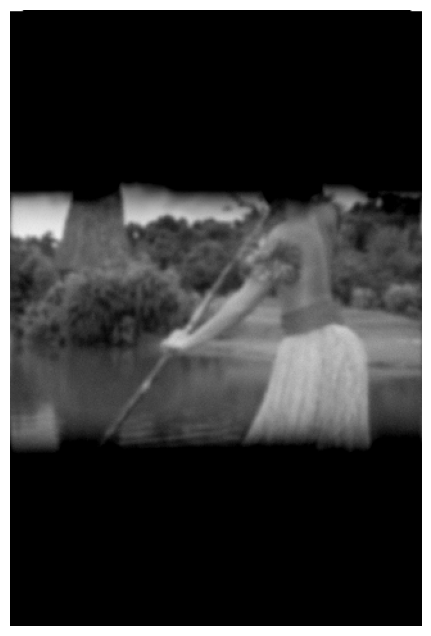

tensor([[[[1622.2942+82.2029j, 1638.2091+82.2440j, 1683.7973+82.3723j,
            ..., 1752.5686+82.5947j, 1683.4410+82.3723j,
           1637.8521+82.2440j],
          [2313.6182+32.0595j, 2332.9917+32.1178j, 2388.2972+32.2837j,
            ..., 2471.2209+32.5269j, 2388.0613+32.2837j,
           2332.7575+32.1178j],
          [3191.2748-1.0745j, 3212.0946-0.9881j, 3271.3346-0.7771j,
            ..., 3360.1261-0.5432j, 3271.4967-0.7771j,
           3212.1165-0.9881j],
          ...,
          [1325.2750-2.7506j, 1327.9895-2.7641j, 1335.5189-2.7945j,
            ..., 1347.0618-2.8233j, 1335.6208-2.7945j,
           1328.1362-2.7641j],
          [1196.8137-22.0220j, 1203.5889-21.9196j, 1222.8466-21.6604j,
            ..., 1252.1728-21.3501j, 1223.0386-21.6604j,
           1203.8306-21.9196j],
          [1213.5911-3.6304j, 1225.0144-3.5959j, 1257.6303-3.4993j,
            ..., 1307.3222-3.3618j, 1257.8960-3.4993j,
           1225.2751-3.5959j]]]], device='cuda:0', dtype=torch.complex128)

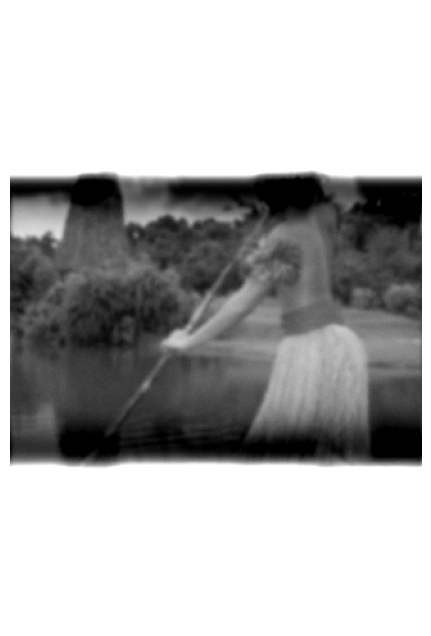

tensor([[[[-145845.2700+123.3044j, -146614.9124+123.3659j, -148834.4849+123.5584j,
            ..., -152251.7397+123.8921j, -148855.4084+123.5584j,
           -146646.3487+123.3659j],
          [-185680.0768+48.0893j, -186582.6437+48.1768j, -189135.7214+48.4255j,
            ..., -193076.4432+48.7903j, -189154.1725+48.4255j,
           -186621.2870+48.1768j],
          [-230886.9072-1.6117j, -231831.1053-1.4821j, -234489.0905-1.1657j,
            ..., -238591.5450-0.8147j, -234500.7259-1.1657j,
           -231831.5922-1.4821j],
          ...,
          [-100409.9907-4.1259j, -100609.4534-4.1461j, -101213.2820-4.1917j,
            ..., -102143.4502-4.2349j, -101190.3680-4.1917j,
           -100572.3207-4.1461j],
          [-104129.5420-33.0330j, -104510.4130-32.8795j, -105646.4891-32.4906j,
            ..., -107395.4098-32.0251j, -105618.8035-32.4906j,
           -104464.4715-32.8795j],
          [-118213.8273-5.4457j, -118795.9349-5.3939j, -120494.6371-5.2490j,
            ..., -123107

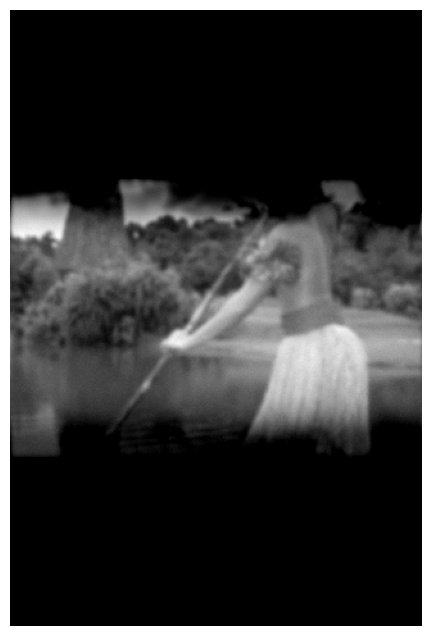

tensor([[[[11809048.7188+164.4058j, 11848316.4465+164.4879j,
           11962975.8341+164.7445j,  ...,
           12144062.6055+165.1895j, 11961143.5163+164.7445j,
           11846382.4513+164.4879j],
          [14252710.0121+64.1191j, 14297179.5319+64.2357j,
           14427025.8122+64.5673j,  ...,
           14629865.6643+65.0537j, 14425387.0662+64.5673j,
           14295281.2676+64.2357j],
          [16945290.2505-2.1489j, 16991491.0246-1.9762j,
           17126384.1878-1.5543j,  ...,
           17338264.4048-1.0863j, 17126088.5504-1.5543j,
           16990659.6105-1.9762j],
          ...,
          [ 7934281.2645-5.5012j,  7949249.7217-5.5282j,
            7991943.4775-5.5890j,  ...,
            8060031.2169-5.6465j,  7992271.5034-5.5890j,
            7949974.5773-5.5282j],
          [ 8613993.9071-44.0441j,  8637732.4556-43.8393j,
            8706213.7279-43.3209j,  ...,
            8815111.6198-42.7002j,  8706589.2244-43.3209j,
            8638735.3869-43.8393j],
          [ 9887

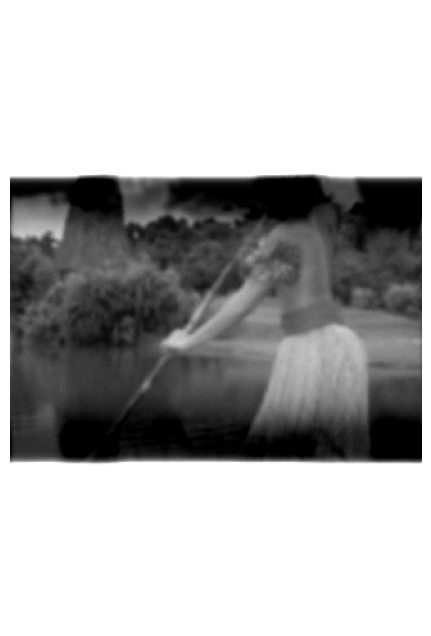

tensor([[[[-9.1686e+08+205.5073j, -9.1912e+08+205.6099j, -9.2566e+08+205.9307j,
            ..., -9.3601e+08+206.4868j, -9.2579e+08+205.9307j,
           -9.1928e+08+205.6099j],
          [-1.0744e+09+80.1488j, -1.0770e+09+80.2946j, -1.0841e+09+80.7091j,
            ..., -1.0955e+09+81.3171j, -1.0843e+09+80.7091j,
           -1.0771e+09+80.2946j],
          [-1.2435e+09-2.6862j, -1.2462e+09-2.4702j, -1.2534e+09-1.9428j,
            ..., -1.2650e+09-1.3579j, -1.2535e+09-1.9428j,
           -1.2461e+09-2.4702j],
          ...,
          [-6.2277e+08-6.8766j, -6.2369e+08-6.9102j, -6.2648e+08-6.9862j,
            ..., -6.3090e+08-7.0581j, -6.2638e+08-6.9862j,
           -6.2351e+08-6.9102j],
          [-6.8718e+08-55.0551j, -6.8854e+08-54.7991j, -6.9268e+08-54.1511j,
            ..., -6.9919e+08-53.3752j, -6.9255e+08-54.1511j,
           -6.8826e+08-54.7991j],
          [-7.8533e+08-9.0761j, -7.8717e+08-8.9898j, -7.9257e+08-8.7483j,
            ..., -8.0107e+08-8.4045j, -7.9235e+08-8.7483j

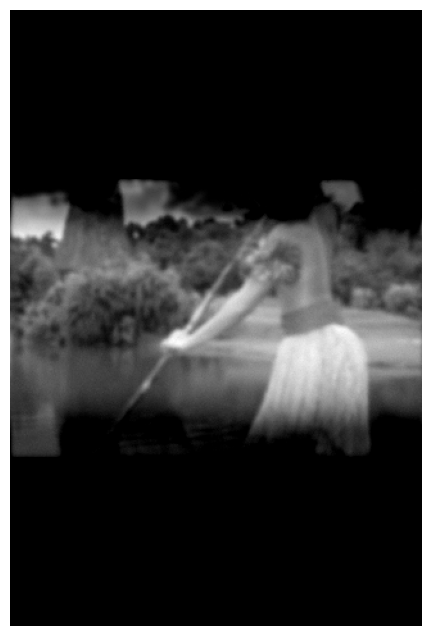

tensor([[[[6.9782e+10+246.6087j, 6.9907e+10+246.7319j, 7.0279e+10+247.1168j,
            ..., 7.0877e+10+247.7842j, 7.0270e+10+247.1168j,
           6.9898e+10+246.7318j],
          [8.0147e+10+96.1786j, 8.0286e+10+96.3535j, 8.0694e+10+96.8510j,
            ..., 8.1342e+10+97.5806j, 8.0686e+10+96.8510j,
           8.0277e+10+96.3535j],
          [9.1063e+10-3.2234j, 9.1205e+10-2.9643j, 9.1625e+10-2.3314j,
            ..., 9.2297e+10-1.6295j, 9.1624e+10-2.3314j,
           9.1202e+10-2.9643j],
          ...,
          [4.8229e+10-8.2519j, 4.8295e+10-8.2922j, 4.8484e+10-8.3834j,
            ..., 4.8791e+10-8.4698j, 4.8486e+10-8.3834j,
           4.8299e+10-8.2922j],
          [5.3493e+10-66.0661j, 5.3583e+10-65.7589j, 5.3843e+10-64.9813j,
            ..., 5.4264e+10-64.0503j, 5.3845e+10-64.9813j,
           5.3589e+10-65.7589j],
          [6.0725e+10-10.8913j, 6.0835e+10-10.7878j, 6.1160e+10-10.4980j,
            ..., 6.1685e+10-10.0854j, 6.1166e+10-10.4980j,
           6.0843e+10-10.787

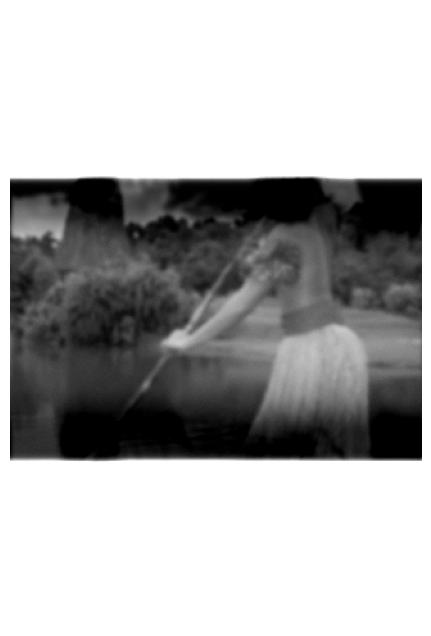

tensor([[[[-5.2458e+12+287.7091j, -5.2538e+12+287.8577j, -5.2768e+12+288.3034j,
            ..., -5.3136e+12+289.0834j, -5.2775e+12+288.3039j,
           -5.2547e+12+287.8533j],
          [-5.9392e+12+112.2074j, -5.9481e+12+112.4120j, -5.9723e+12+112.9920j,
            ..., -6.0121e+12+113.8442j, -5.9733e+12+112.9943j,
           -5.9490e+12+112.4140j],
          [-6.6562e+12-3.7580j, -6.6651e+12-3.4568j, -6.6896e+12-2.7185j,
            ..., -6.7291e+12-1.9011j, -6.6898e+12-2.7170j,
           -6.6649e+12-3.4577j],
          ...,
          [-3.6965e+12-9.6280j, -3.7004e+12-9.6746j, -3.7125e+12-9.7802j,
            ..., -3.7318e+12-9.8811j, -3.7120e+12-9.7821j,
           -3.6994e+12-9.6734j],
          [-4.1030e+12-77.0757j, -4.1081e+12-76.7188j, -4.1243e+12-75.8110j,
            ..., -4.1497e+12-74.7253j, -4.1235e+12-75.8125j,
           -4.1065e+12-76.7176j],
          [-4.6240e+12-12.7061j, -4.6306e+12-12.5868j, -4.6503e+12-12.2486j,
            ..., -4.6814e+12-11.7679j, -4.6490e+

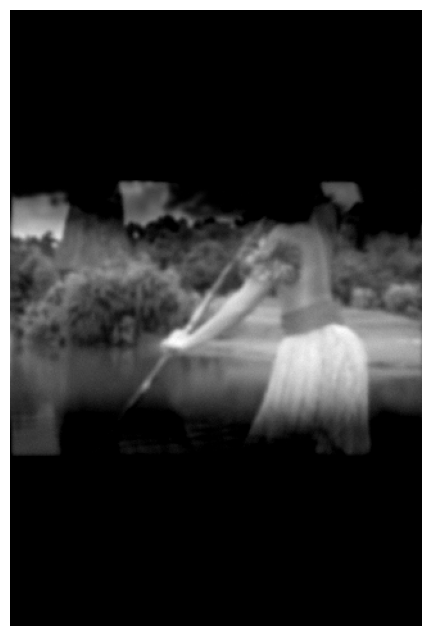

tensor([[[[3.9139e+14+328.6424j, 3.9185e+14+328.8522j, 3.9322e+14+329.5739j,
            ..., 3.9544e+14+330.2926j, 3.9316e+14+329.4518j,
           3.9180e+14+329.0012j],
          [4.3804e+14+128.3967j, 4.3854e+14+128.5707j, 4.4002e+14+129.3039j,
            ..., 4.4238e+14+130.0335j, 4.3997e+14+129.0610j,
           4.3850e+14+128.6646j],
          [4.8560e+14-4.2793j, 4.8611e+14-4.0087j, 4.8762e+14-3.1477j,
            ..., 4.9006e+14-2.1771j, 4.8762e+14-3.0850j,
           4.8610e+14-3.9483j],
          ...,
          [2.8056e+14-11.0385j, 2.8086e+14-10.9931j, 2.8168e+14-11.0987j,
            ..., 2.8303e+14-11.2609j, 2.8169e+14-11.1006j,
           2.8087e+14-10.8999j],
          [3.1101e+14-88.0526j, 3.1138e+14-87.6650j, 3.1243e+14-86.5733j,
            ..., 3.1414e+14-85.3955j, 3.1244e+14-86.6360j,
           3.1142e+14-87.5718j],
          [3.4832e+14-14.4538j, 3.4875e+14-14.4265j, 3.4998e+14-14.1189j,
            ..., 3.5201e+14-13.3623j, 3.5002e+14-14.0269j,
           3.487

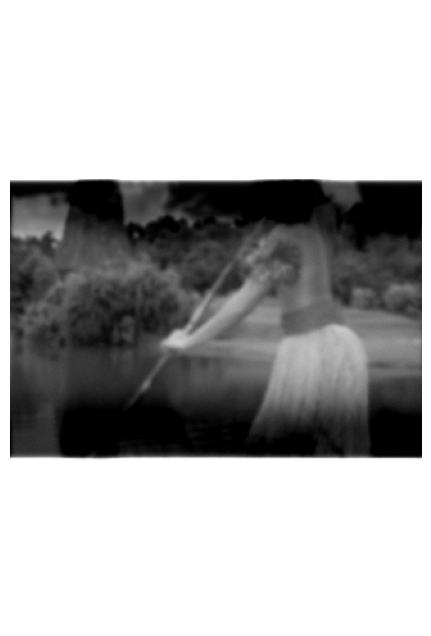

tensor([[[[-2.9029e+16+362.0022j, -2.9061e+16+368.0990j, -2.9150e+16+370.7831j,
            ..., -2.9293e+16+375.4265j, -2.9154e+16+372.6233j,
           -2.9065e+16+372.1727j],
          [-3.2199e+16+144.0955j, -3.2234e+16+148.1941j, -3.2325e+16+148.9273j,
            ..., -3.2478e+16+149.6569j, -3.2331e+16+148.6844j,
           -3.2239e+16+148.2880j],
          [-3.5381e+16-4.2793j, -3.5416e+16-11.8580j, -3.5507e+16-7.0724j,
            ..., -3.5656e+16-13.9511j, -3.5508e+16-14.8590j,
           -3.5414e+16-3.9483j],
          ...,
          [-2.1159e+16-9.0761j, -2.1176e+16-14.9178j, -2.1229e+16-13.0610j,
            ..., -2.1312e+16-13.2233j, -2.1226e+16-11.1006j,
           -2.1170e+16-10.8999j],
          [-2.3408e+16-99.8266j, -2.3429e+16-103.3637j, -2.3495e+16-94.4226j,
            ..., -2.3599e+16-99.1319j, -2.3491e+16-96.4477j,
           -2.3420e+16-101.3082j],
          [-2.6058e+16-8.5668j, -2.6084e+16-8.5394j, -2.6162e+16-20.0059j,
            ..., -2.6284e+16-15.3247j, -

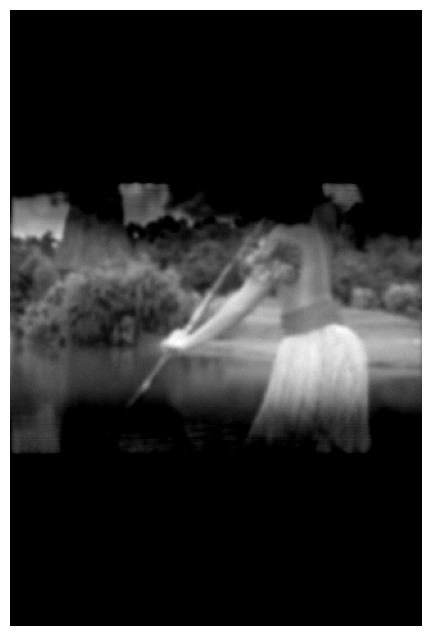

tensor([[[[2.1448e+18-265.9471j, 2.1466e+18-8.6705j, 2.1520e+18-633.9357j,
            ..., 2.1609e+18-378.1126j, 2.1518e+18-4.1463j,
           2.1464e+18+120.9930j],
          [2.3604e+18-107.0842j, 2.3623e+18-354.1653j, 2.3681e+18+651.2867j,
            ..., 2.3774e+18-101.5228j, 2.3679e+18+399.8641j,
           2.3621e+18-102.8917j],
          [2.5741e+18-255.4590j, 2.5761e+18-11.8580j, 2.5821e+18-258.2521j,
            ..., 2.5917e+18-13.9511j, 2.5820e+18-14.8590j,
           2.5761e+18+498.4111j],
          ...,
          [1.5854e+18-9.0761j, 1.5867e+18-266.0975j, 1.5903e+18-264.2407j,
            ..., 1.5963e+18+363.5463j, 1.5904e+18-136.6904j,
           1.5868e+18-262.0796j],
          [1.7496e+18+151.3531j, 1.7511e+18+22.2261j, 1.7555e+18-94.4226j,
            ..., 1.7628e+18-224.7218j, 1.7556e+18-222.0376j,
           1.7513e+18-101.3082j],
          [1.9380e+18-385.3363j, 1.9397e+18-510.8988j, 1.9448e+18-271.1856j,
            ..., 1.9531e+18-15.3247j, 1.9450e+18-394.7211j,

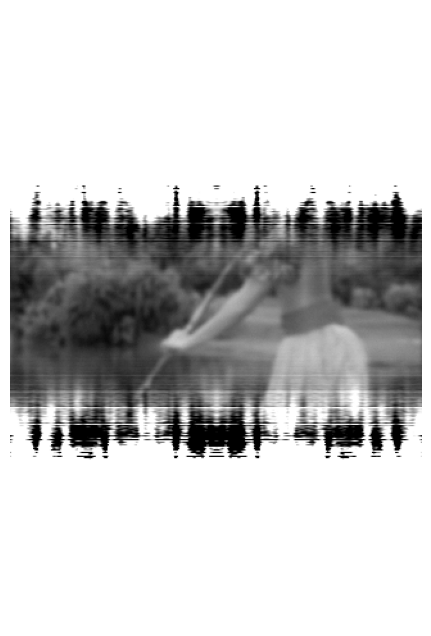

tensor([[[[-1.5791e+20-16341.4474j, -1.5804e+20+32142.3301j,
           -1.5840e+20-633.9357j,  ...,
           -1.5899e+20+31772.8880j, -1.5842e+20+32146.8544j,
           -1.5806e+20+16196.4933j],
          [-1.7268e+20-64409.0855j, -1.7282e+20-32505.1659j,
           -1.7319e+20-47575.2142j,  ...,
           -1.7381e+20-64403.5240j, -1.7322e+20-63902.1372j,
           -1.7285e+20-80480.3933j],
          [-1.8711e+20-32406.4596j, -1.8725e+20-64313.8593j,
           -1.8762e+20-16333.7524j,  ...,
           -1.8821e+20-16089.4514j, -1.8762e+20-48241.3600j,
           -1.8724e+20-31652.5896j],
          ...,
          [-1.1831e+20-32160.0768j, -1.1839e+20-48492.5984j,
           -1.1862e+20-48490.7416j,  ...,
           -1.1899e+20-39825.2045j, -1.1860e+20-56400.9415j,
           -1.1836e+20-40450.8304j],
          [-1.3026e+20+16226.8534j, -1.3034e+20-8015.5240j,
           -1.3062e+20+15981.0777j,  ...,
           -1.3106e+20+15850.7786j, -1.3060e+20-222.0376j,
           -1.3029e+20

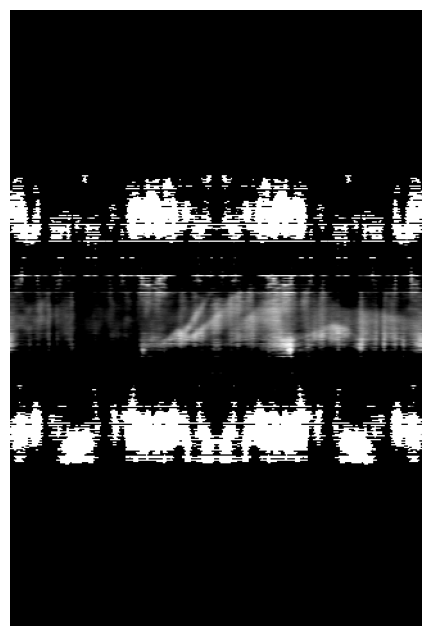

tensor([[[[1.1598e+22-1.6341e+04j, 1.1606e+22+2.0898e+06j,
           1.1628e+22+1.0282e+06j,  ...,
           1.1665e+22-9.9706e+05j, 1.1627e+22+3.1186e+06j,
           1.1605e+22+3.1027e+06j],
          [1.2609e+22+9.6442e+05j, 1.2617e+22+5.1117e+06j,
           1.2641e+22+9.8126e+05j,  ...,
           1.2679e+22+9.6443e+05j, 1.2639e+22+4.0514e+06j,
           1.2616e+22-2.1381e+06j],
          [1.3585e+22-1.0612e+06j, 1.3593e+22-3.1508e+06j,
           1.3617e+22-2.0740e+06j,  ...,
           1.3657e+22-1.6089e+04j, 1.3617e+22+4.0671e+06j,
           1.3593e+22-1.0605e+06j],
          ...,
          [8.7890e+21+4.8226e+05j, 8.7949e+21-4.8493e+04j,
           8.8114e+21+4.6593e+05j,  ...,
           8.8384e+21-3.9825e+04j, 8.8117e+21-1.0852e+06j,
           8.7955e+21-1.0693e+06j],
          [9.6518e+21+2.0739e+06j, 9.6587e+21-8.0155e+03j,
           9.6778e+21+1.0448e+06j,  ...,
           9.7094e+21+2.0735e+06j, 9.6783e+21-2.2204e+02j,
           9.6599e+21+3.2050e+04j],
          

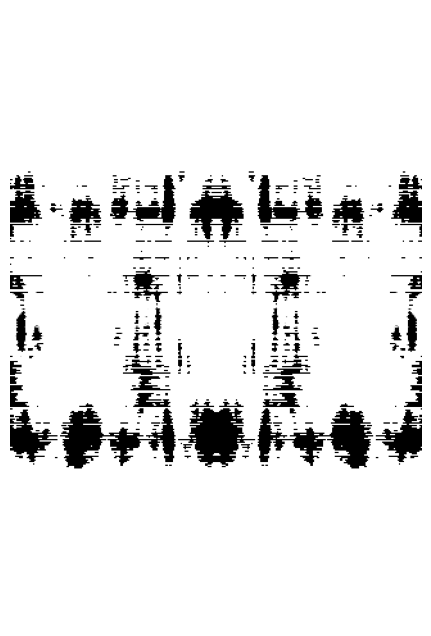

tensor([[[[-8.4982e+23+2.6336e+08j, -8.5039e+23-6.3755e+07j,
           -8.5195e+23-6.4817e+07j,  ...,
           -8.5449e+23-9.9706e+05j, -8.5206e+23+6.8964e+07j,
           -8.5052e+23+3.1027e+06j],
          [-9.1939e+23-1.3073e+08j, -9.2000e+23-1.2658e+08j,
           -9.2156e+23-6.4864e+07j,  ...,
           -9.2422e+23-1.9657e+08j, -9.2173e+23-1.2764e+08j,
           -9.2015e+23+6.3707e+07j],
          [-9.8564e+23-6.6906e+07j, -9.8623e+23-6.8996e+07j,
           -9.8777e+23-2.0740e+06j,  ...,
           -9.9025e+23-1.6089e+04j, -9.8779e+23+1.3576e+08j,
           -9.8619e+23-1.0605e+06j],
          ...,
          [-6.5123e+23-1.3121e+08j, -6.5157e+23-6.5894e+07j,
           -6.5260e+23+6.6311e+07j,  ...,
           -6.5423e+23-6.5885e+07j, -6.5251e+23-1.0852e+06j,
           -6.5140e+23-2.6445e+08j],
          [-7.1355e+23-1.2962e+08j, -7.1391e+23+6.5837e+07j,
           -7.1514e+23+1.0448e+06j,  ...,
           -7.1702e+23+6.7919e+07j, -7.1501e+23-1.9754e+08j,
           -7.136

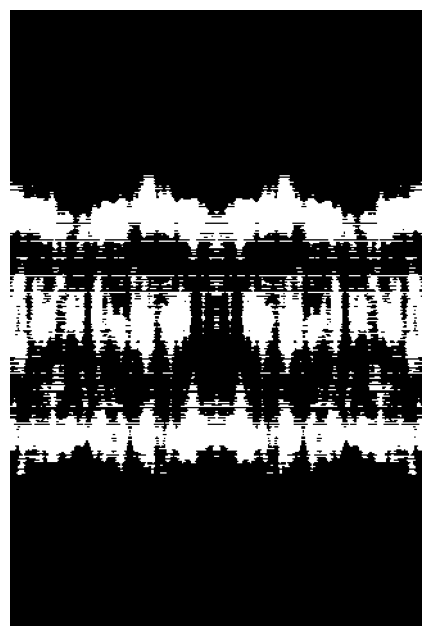

tensor([[[[6.2172e+25+4.4775e+09j, 6.2203e+25+4.1503e+09j,
           6.2300e+25-1.2707e+10j,  ...,
           6.2459e+25-9.9706e+05j, 6.2292e+25+6.8964e+07j,
           6.2197e+25-1.2639e+10j],
          [6.6946e+25-1.2773e+10j, 6.6981e+25-2.5411e+10j,
           6.7083e+25-1.2707e+10j,  ...,
           6.7247e+25-4.4107e+09j, 6.7077e+25-1.2770e+10j,
           6.6976e+25+6.3707e+07j],
          [7.1439e+25-6.6906e+07j, 7.1474e+25-6.8996e+07j,
           7.1579e+25+4.2120e+09j,  ...,
           7.1749e+25-1.6089e+04j, 7.1579e+25+1.3576e+08j,
           7.1474e+25-1.2643e+10j],
          ...,
          [4.8084e+25-8.5594e+09j, 4.8112e+25-2.9565e+10j,
           4.8186e+25+8.4945e+09j,  ...,
           4.8310e+25+8.3623e+09j, 4.8188e+25-4.2152e+09j,
           4.8115e+25-4.4785e+09j],
          [5.2564e+25-4.3437e+09j, 5.2595e+25-8.3624e+09j,
           5.2680e+25+1.0448e+06j,  ...,
           5.2821e+25+6.7919e+07j, 5.2683e+25+4.0166e+09j,
           5.2601e+25-1.2774e+10j],
          

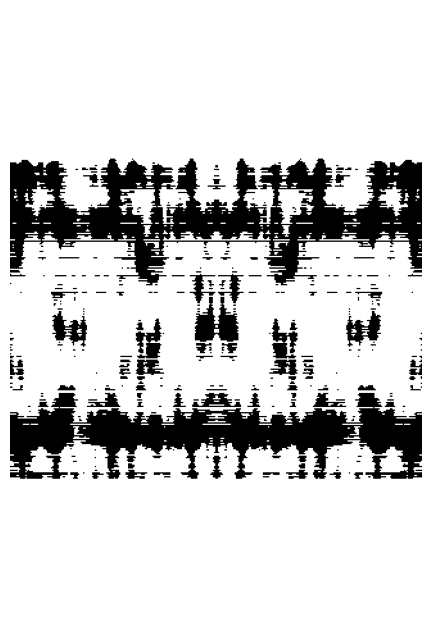

tensor([[[[-4.5399e+27-1.3440e+12j, -4.5424e+27-1.0747e+12j,
           -4.5493e+27-5.5211e+11j,  ...,
           -4.5605e+27-5.3941e+11j, -4.5499e+27-2.6963e+11j,
           -4.5431e+27+5.2677e+11j],
          [-4.8697e+27+1.6054e+12j, -4.8724e+27+5.1399e+11j,
           -4.8792e+27+5.2670e+11j,  ...,
           -4.8908e+27-5.4381e+11j, -4.8800e+27-1.2770e+10j,
           -4.8732e+27+5.3947e+11j],
          [-5.1754e+27+5.3934e+11j, -5.1780e+27+5.3934e+11j,
           -5.1846e+27+4.2120e+09j,  ...,
           -5.1953e+27+5.3940e+11j, -5.1847e+27+1.6183e+12j,
           -5.1778e+27+5.2676e+11j],
          ...,
          [-3.5444e+27-8.1767e+11j, -3.5460e+27+7.7954e+11j,
           -3.5506e+27-8.0061e+11j,  ...,
           -3.5579e+27-5.3104e+11j, -3.5501e+27-8.1332e+11j,
           -3.5450e+27-2.7418e+11j],
          [-3.8668e+27+1.8836e+12j, -3.8684e+27+2.6134e+11j,
           -3.8738e+27+1.0448e+06j,  ...,
           -3.8821e+27+8.0917e+11j, -3.8731e+27+2.7372e+11j,
           -3.866

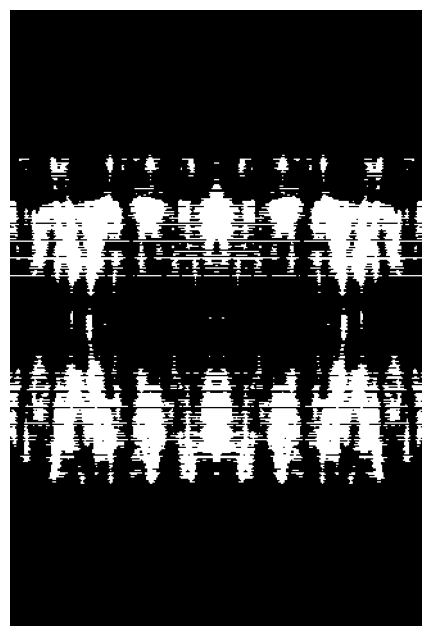

tensor([[[[3.3115e+29+6.7700e+13j, 3.3129e+29+3.3447e+13j,
           3.3171e+29-5.5211e+11j,  ...,
           3.3242e+29+6.8504e+13j, 3.3167e+29+6.8774e+13j,
           3.3126e+29+6.9571e+13j],
          [3.5383e+29+1.6054e+12j, 3.5398e+29+3.5036e+13j,
           3.5443e+29+6.9570e+13j,  ...,
           3.5515e+29-5.4381e+11j, 3.5439e+29+3.4509e+13j,
           3.5395e+29+1.0411e+14j],
          [3.7459e+29+5.3934e+11j, 3.7474e+29-6.8504e+13j,
           3.7520e+29-3.4518e+13j,  ...,
           3.7595e+29+5.3940e+11j, 3.7520e+29+7.0662e+13j,
           3.7474e+29+5.2676e+11j],
          ...,
          [2.6053e+29-5.2600e+13j, 2.6066e+29+7.7954e+11j,
           2.6101e+29-3.5322e+13j,  ...,
           2.6158e+29-1.7792e+13j, 2.6102e+29-5.2596e+13j,
           2.6068e+29-1.7535e+13j],
          [2.8364e+29-1.5377e+13j, 2.8379e+29-1.7000e+13j,
           2.8417e+29+1.0448e+06j,  ...,
           2.8481e+29+8.0917e+11j, 2.8419e+29+2.7372e+11j,
           2.8382e+29+1.7788e+13j],
          

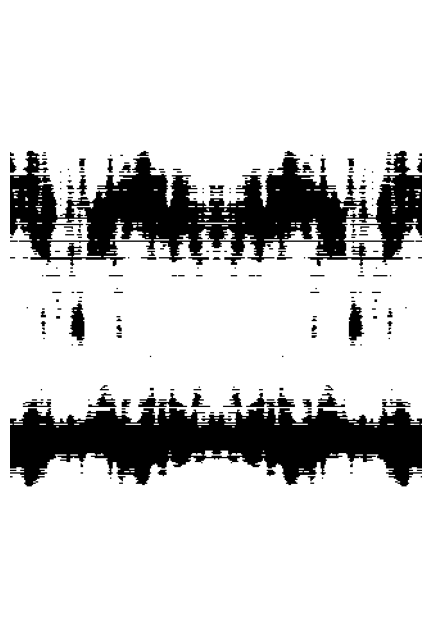

tensor([[[[-2.4119e+31+8.9053e+15j, -2.4130e+31-2.1760e+15j,
           -2.4161e+31-5.5211e+11j,  ...,
           -2.4211e+31+6.8504e+13j, -2.4164e+31+6.8774e+13j,
           -2.4134e+31+6.9571e+13j],
          [-2.5688e+31+6.6298e+15j, -2.5700e+31+2.2444e+15j,
           -2.5730e+31+2.2790e+15j,  ...,
           -2.5783e+31+4.4183e+15j, -2.5735e+31-2.1749e+15j,
           -2.5704e+31+1.0411e+14j],
          [-2.7102e+31-2.2089e+15j, -2.7114e+31-6.8504e+13j,
           -2.7143e+31+4.3843e+15j,  ...,
           -2.7190e+31+2.2099e+15j, -2.7143e+31+7.0662e+13j,
           -2.7113e+31-6.6277e+15j],
          ...,
          [-1.9129e+31-5.5761e+15j, -1.9136e+31-1.1046e+16j,
           -1.9157e+31-6.6635e+15j,  ...,
           -1.9191e+31-6.6460e+15j, -1.9155e+31-8.8902e+15j,
           -1.9131e+31-6.6457e+15j],
          [-2.0789e+31-1.5377e+13j, -2.0796e+31+4.4018e+15j,
           -2.0821e+31+2.2094e+15j,  ...,
           -2.0858e+31+6.6290e+15j, -2.0817e+31+6.6285e+15j,
           -2.078

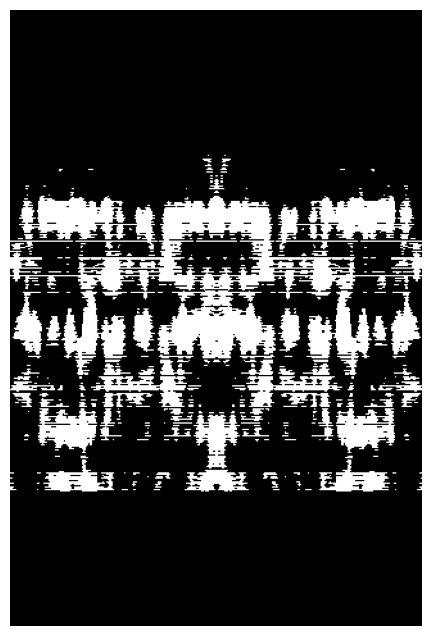

tensor([[[[1.7552e+33-6.9810e+17j, 1.7558e+33-4.2638e+17j,
           1.7577e+33-5.6561e+17j,  ...,
           1.7609e+33-4.2414e+17j, 1.7575e+33-7.0694e+17j,
           1.7557e+33-4.2414e+17j],
          [1.8632e+33-1.3477e+17j, 1.8639e+33-4.2196e+17j,
           1.8659e+33-1.3912e+17j,  ...,
           1.8691e+33+1.4582e+17j, 1.8657e+33-1.4358e+17j,
           1.8638e+33+1.4151e+17j],
          [1.9593e+33+5.6340e+17j, 1.9599e+33+5.6554e+17j,
           1.9620e+33+5.6999e+17j,  ...,
           1.9654e+33+2.2099e+15j, 1.9620e+33-1.4133e+17j,
           1.9599e+33-6.6277e+15j],
          ...,
          [1.4012e+33+2.7723e+17j, 1.4018e+33+6.9596e+17j,
           1.4034e+33-6.6635e+15j,  ...,
           1.4061e+33+1.3476e+17j, 1.4035e+33-8.8902e+15j,
           1.4019e+33-6.6457e+15j],
          [1.5200e+33-4.2422e+17j, 1.5207e+33+4.4018e+15j,
           1.5224e+33-2.8059e+17j,  ...,
           1.5254e+33+6.6290e+15j, 1.5225e+33+1.4803e+17j,
           1.5209e+33+1.5468e+17j],
          

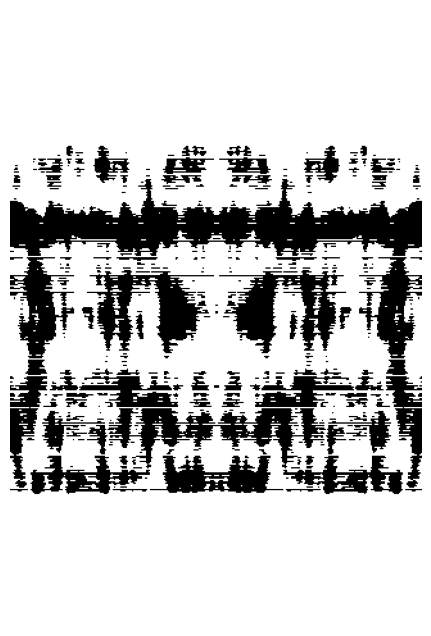

tensor([[[[-1.2758e+35-6.9810e+17j, -1.2763e+35+8.6233e+18j,
           -1.2777e+35-5.6561e+17j,  ...,
           -1.2800e+35-2.7573e+19j, -1.2779e+35-9.7566e+18j,
           -1.2765e+35-1.8524e+19j],
          [-1.3506e+35+1.7965e+19j, -1.3511e+35+2.6727e+19j,
           -1.3525e+35-2.7288e+19j,  ...,
           -1.3549e+35+1.8245e+19j, -1.3528e+35+8.9061e+18j,
           -1.3514e+35+1.4151e+17j],
          [-1.4160e+35-2.6586e+19j, -1.4165e+35-8.4842e+18j,
           -1.4178e+35+1.8669e+19j,  ...,
           -1.4199e+35+2.7151e+19j, -1.4178e+35-1.4133e+17j,
           -1.4165e+35+9.0431e+18j],
          ...,
          [-1.0257e+35+2.7723e+17j, -1.0260e+35+6.9596e+17j,
           -1.0270e+35+2.7142e+19j,  ...,
           -1.0285e+35-1.7965e+19j, -1.0268e+35-9.0586e+18j,
           -1.0257e+35+9.0431e+18j],
          [-1.1109e+35+8.6255e+18j, -1.1112e+35+2.7154e+19j,
           -1.1123e+35+1.7819e+19j,  ...,
           -1.1140e+35-1.8093e+19j, -1.1121e+35+1.4803e+17j,
           -1.110

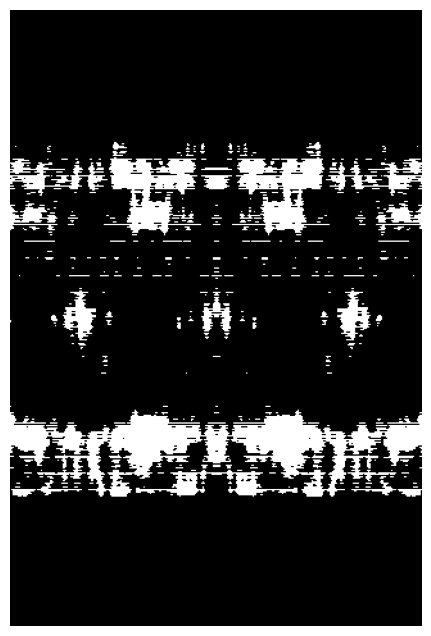

tensor([[[[9.2669e+36-5.7988e+20j, 9.2696e+36-1.1497e+21j,
           9.2784e+36-5.7975e+20j,  ...,
           9.2928e+36-6.0675e+20j, 9.2773e+36-5.8894e+20j,
           9.2689e+36-1.1769e+21j],
          [9.7820e+36+2.3347e+21j, 9.7851e+36+2.3435e+21j,
           9.7943e+36+3.4478e+21j,  ...,
           9.8089e+36+1.8245e+19j, 9.7934e+36+2.3256e+21j,
           9.7845e+36+1.1585e+21j],
          [1.0226e+37-6.0577e+20j, 1.0229e+37-5.8767e+20j,
           1.0238e+37+1.8669e+19j,  ...,
           1.0254e+37-4.0271e+21j, 1.0239e+37-1.7377e+21j,
           1.0229e+37-1.7285e+21j],
          ...,
          [7.4924e+36+2.7723e+17j, 7.4952e+36-5.7848e+20j,
           7.5028e+36+2.7142e+19j,  ...,
           7.5153e+36-1.7965e+19j, 7.5031e+36+1.1493e+21j,
           7.4958e+36+9.0431e+18j],
          [8.1012e+36+1.7462e+21j, 8.1043e+36+6.0633e+20j,
           8.1126e+36+5.9700e+20j,  ...,
           8.1262e+36+5.6109e+20j, 8.1130e+36-5.7903e+20j,
           8.1054e+36-5.8808e+20j],
          

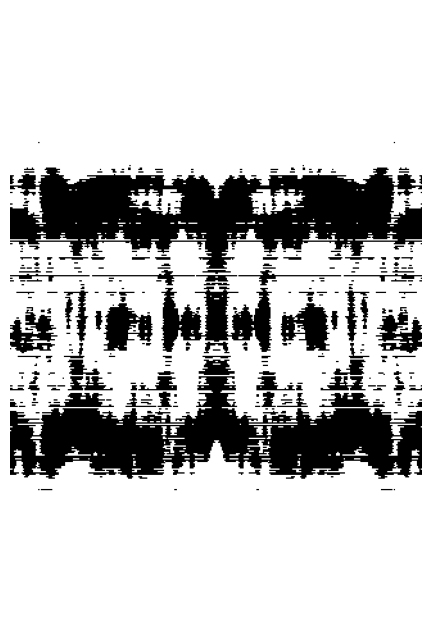

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


/tmp/ipykernel_3404/3646455709.py:8: RuntimeWarning: invalid value encountered in cast
  return np.uint8((img*255.0).round())


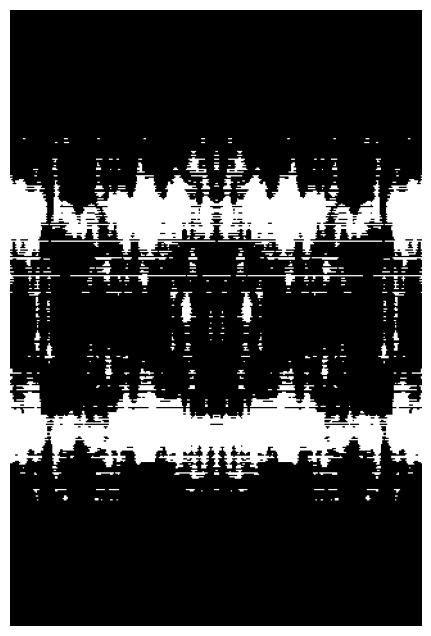

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


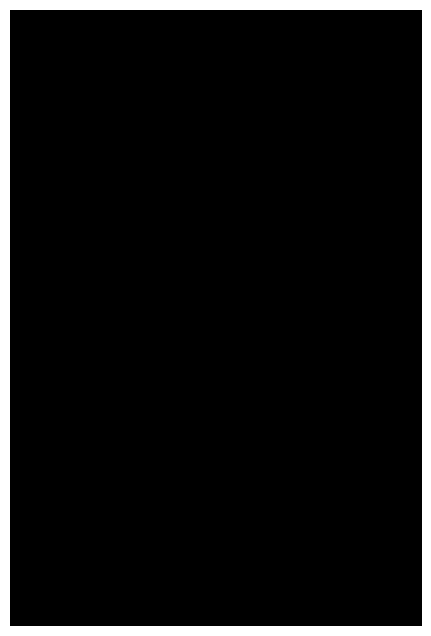

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


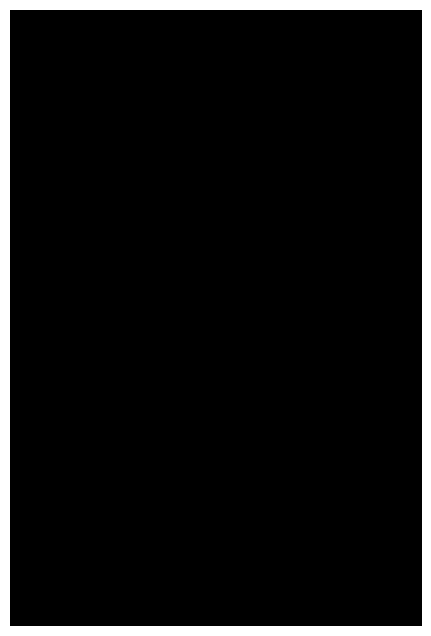

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


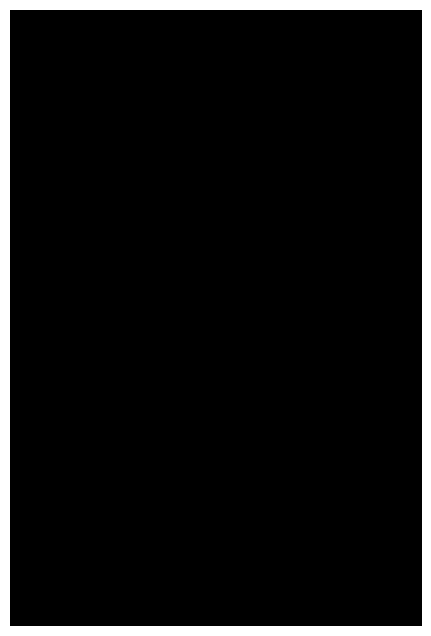

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


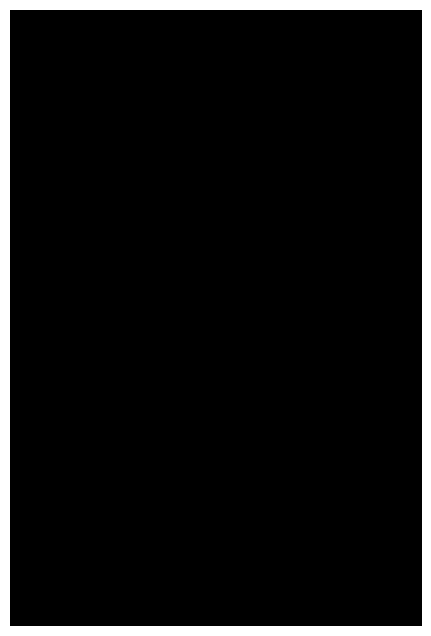

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


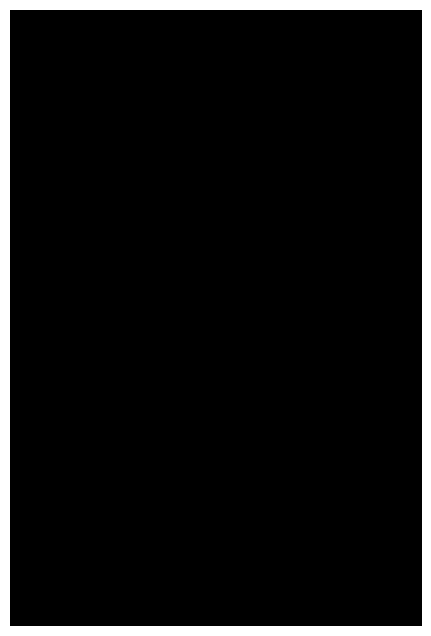

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


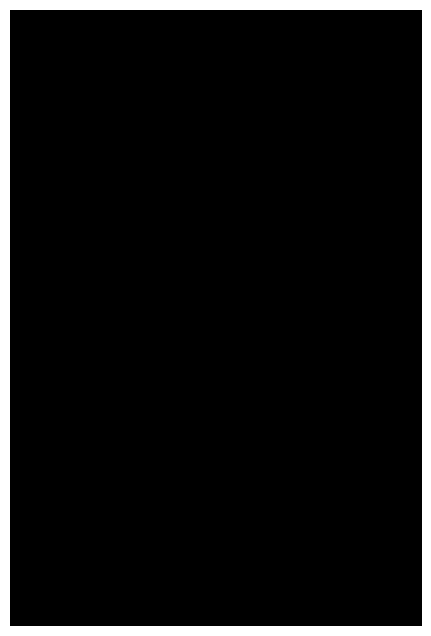

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


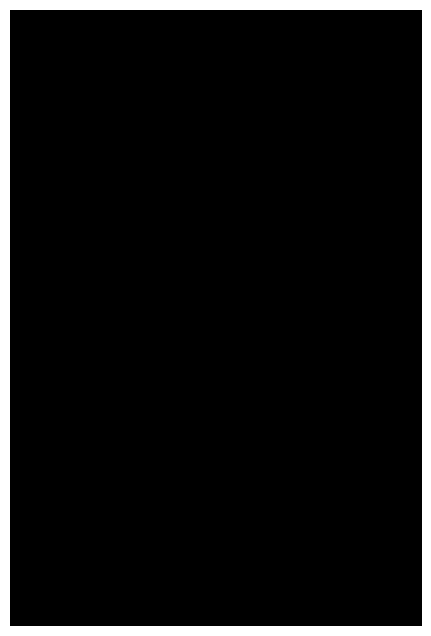

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


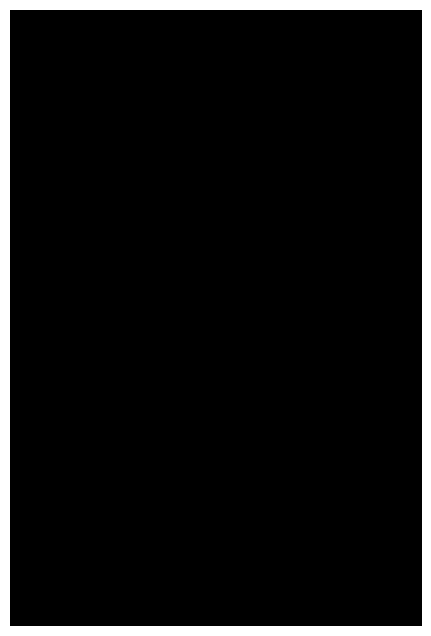

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


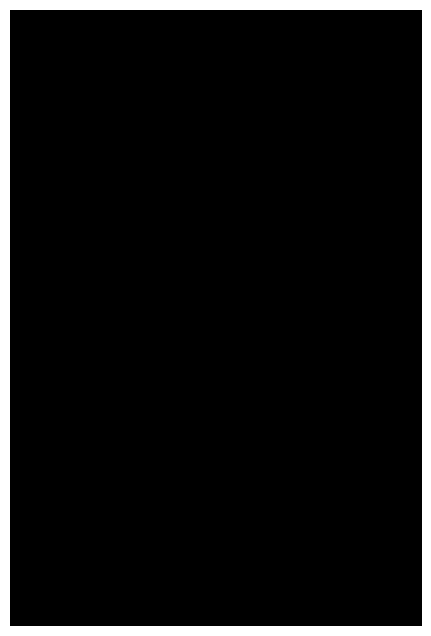

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


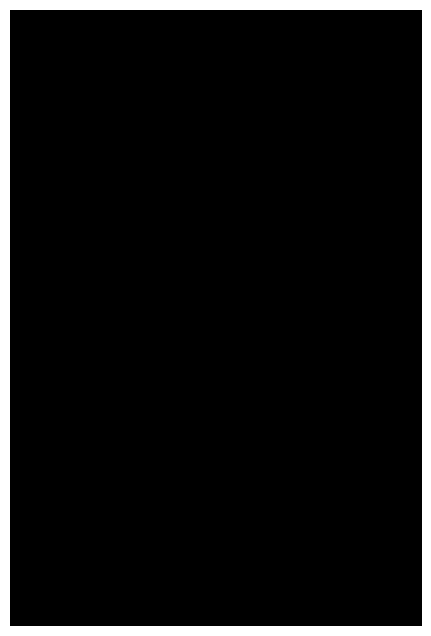

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


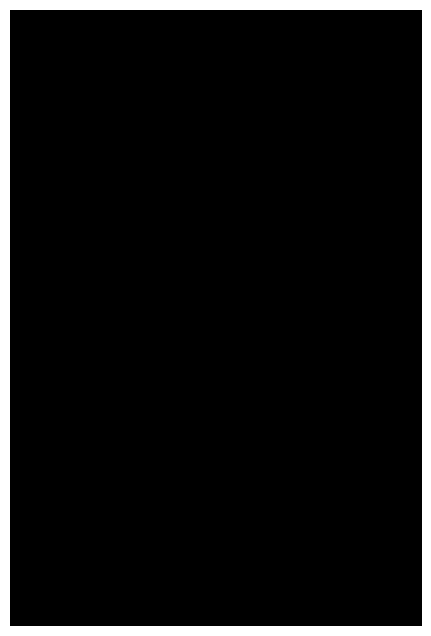

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


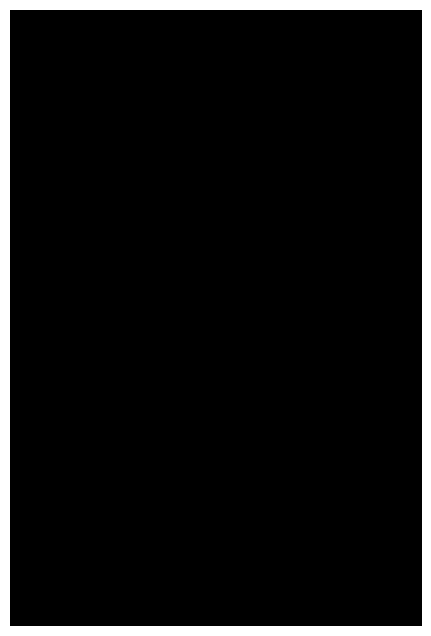

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


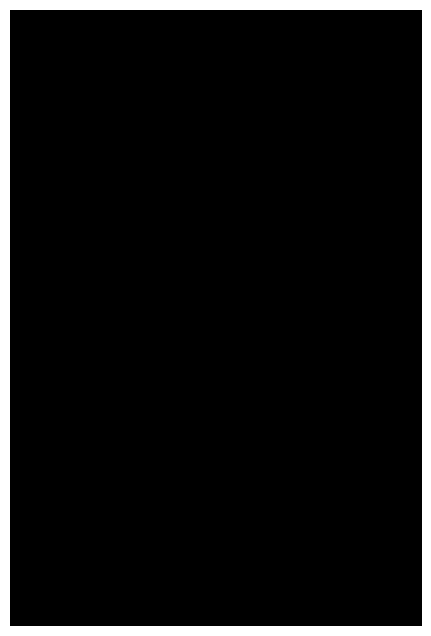

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


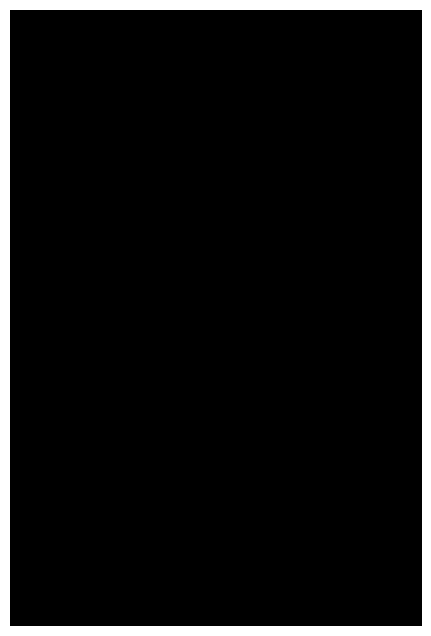

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


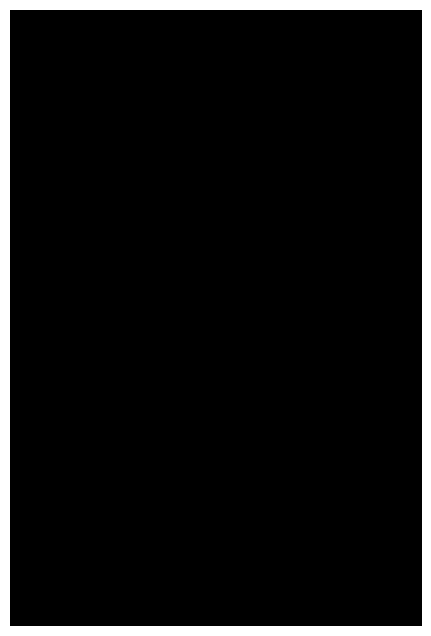

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


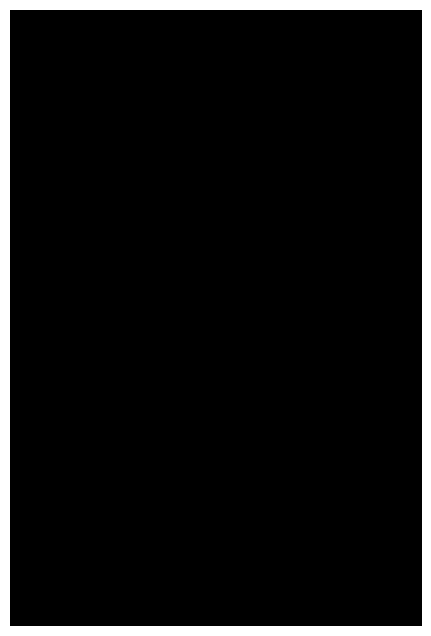

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


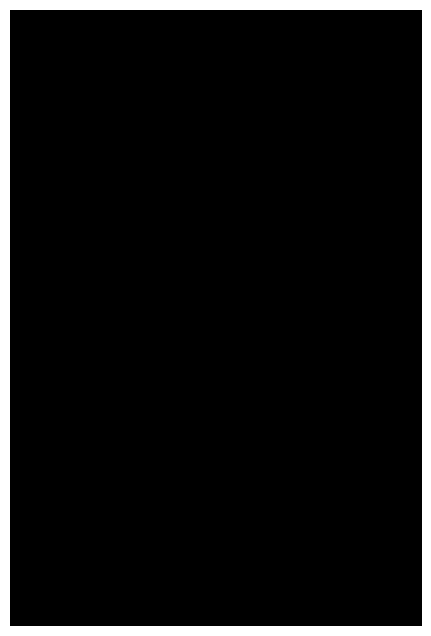

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


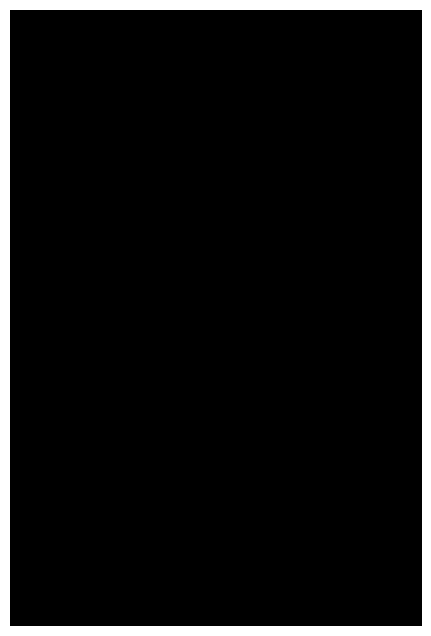

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


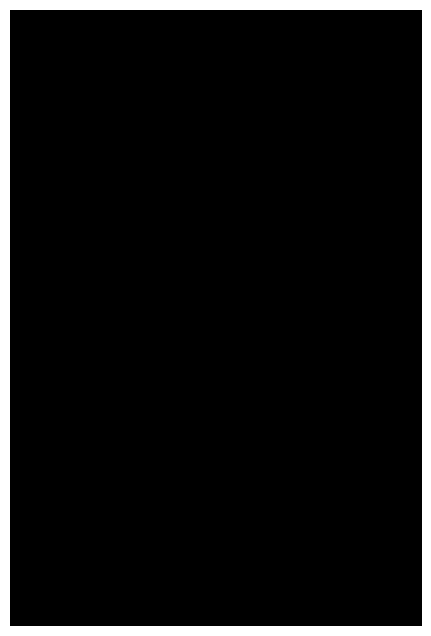

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


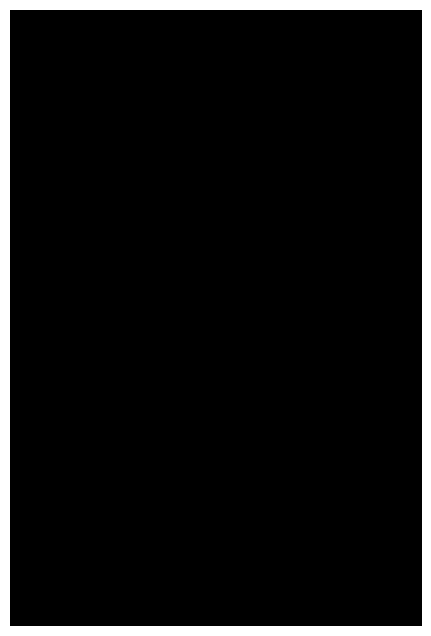

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


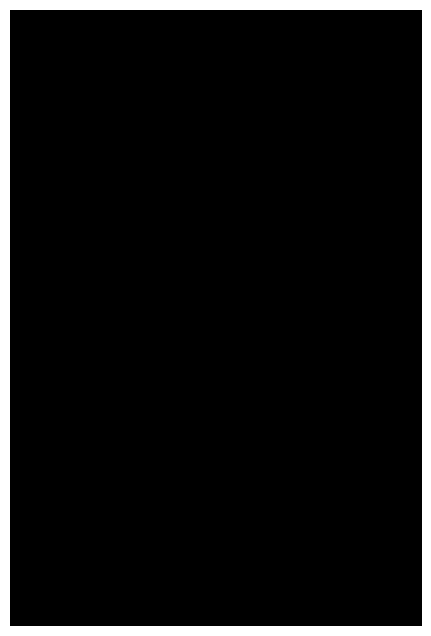

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


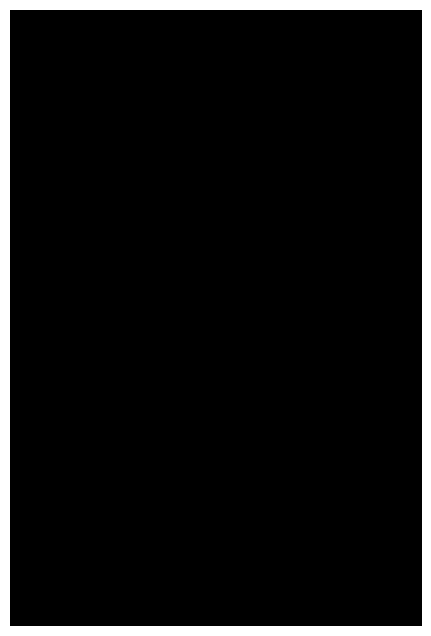

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


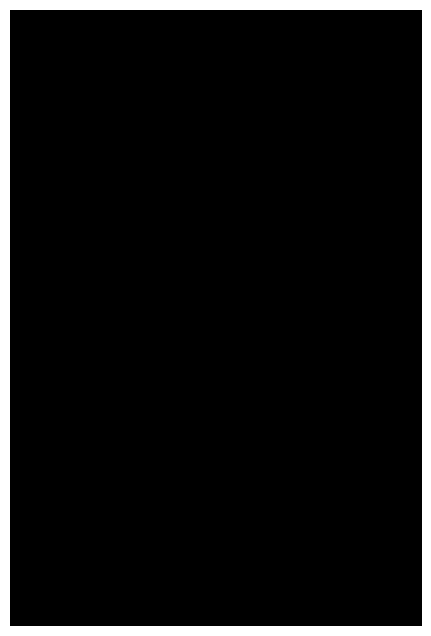

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


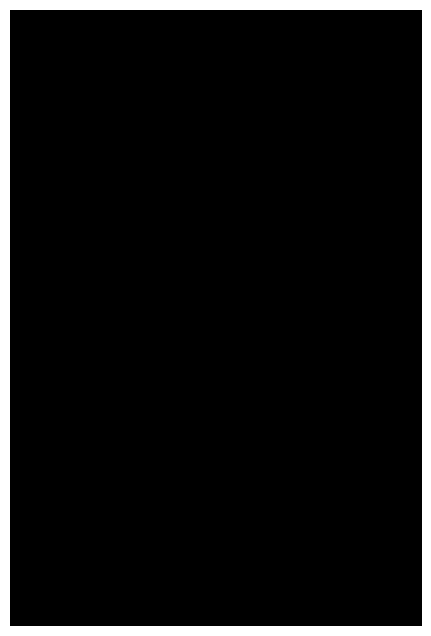

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


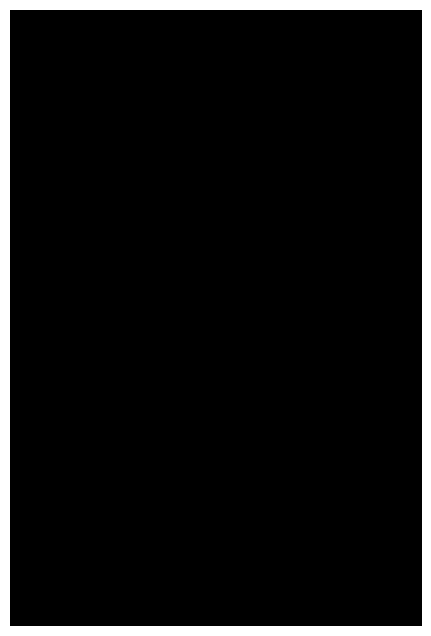

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


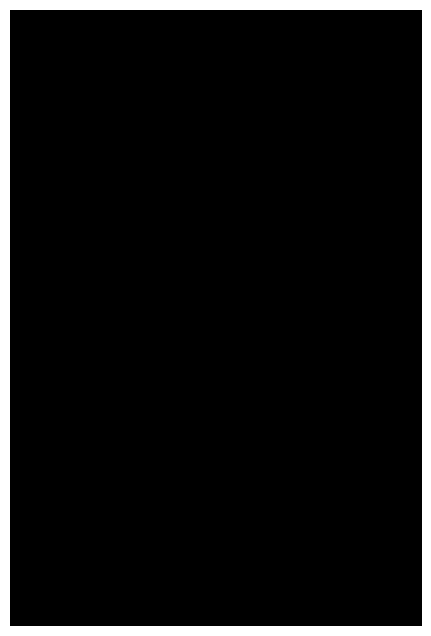

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


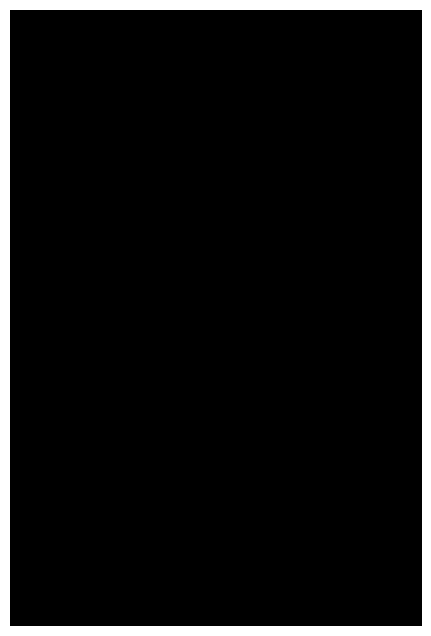

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


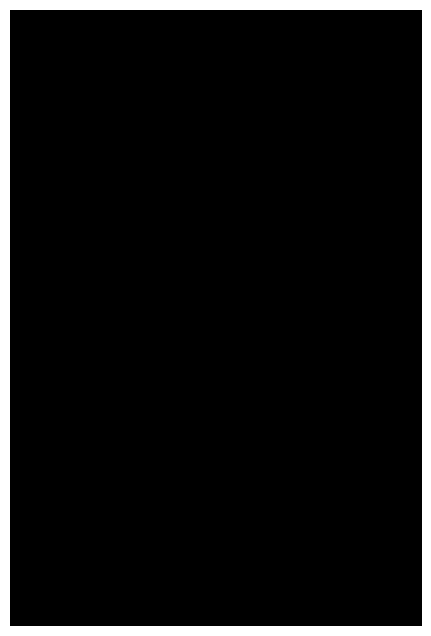

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


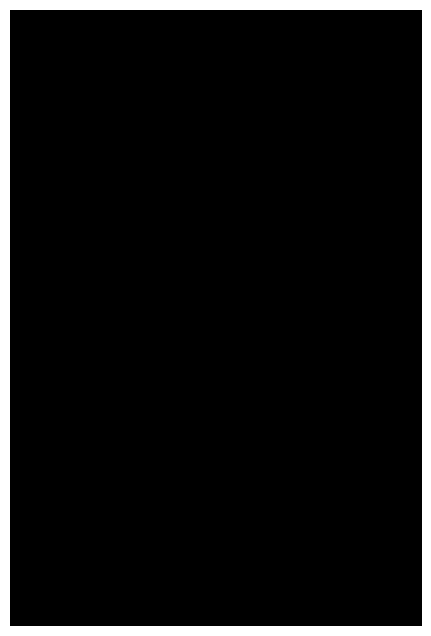

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


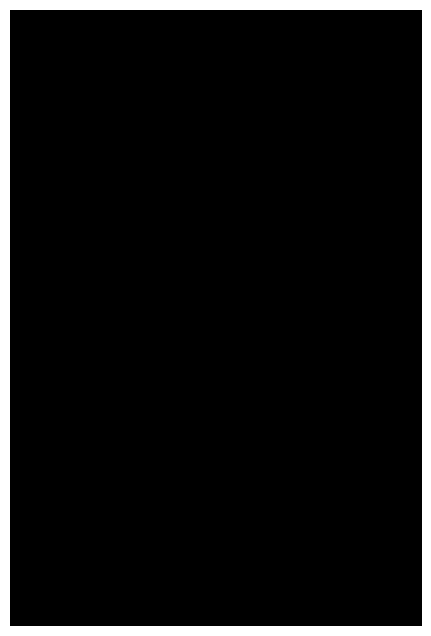

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


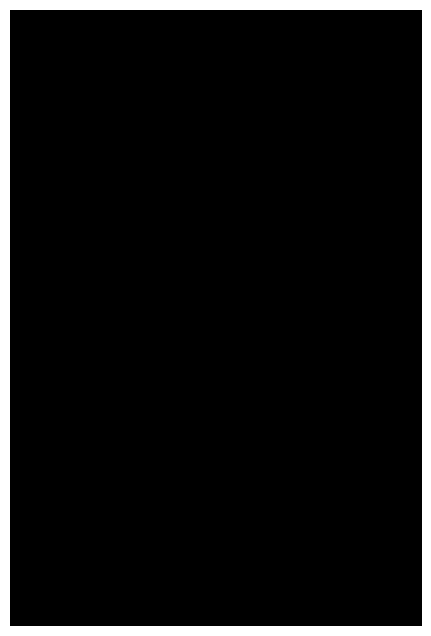

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


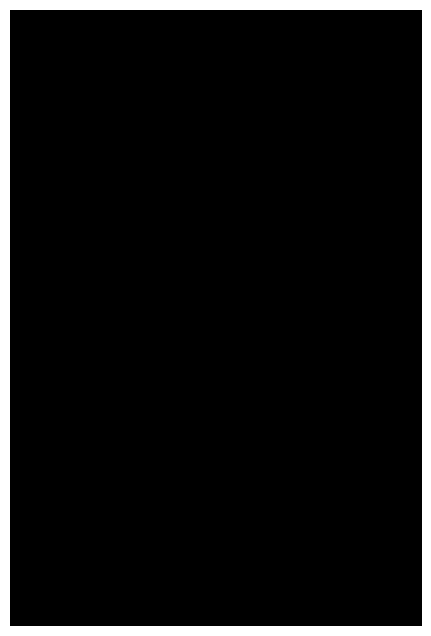

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


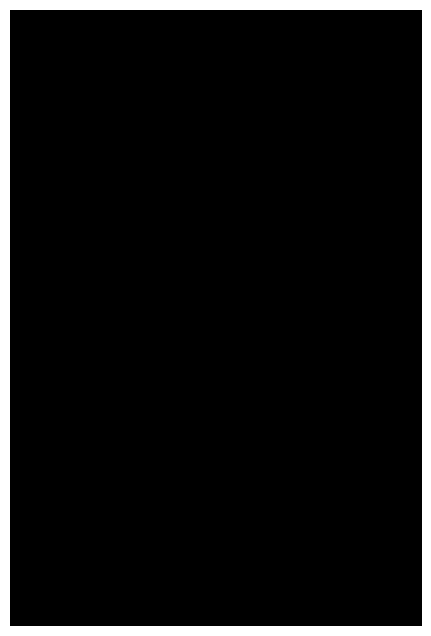

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


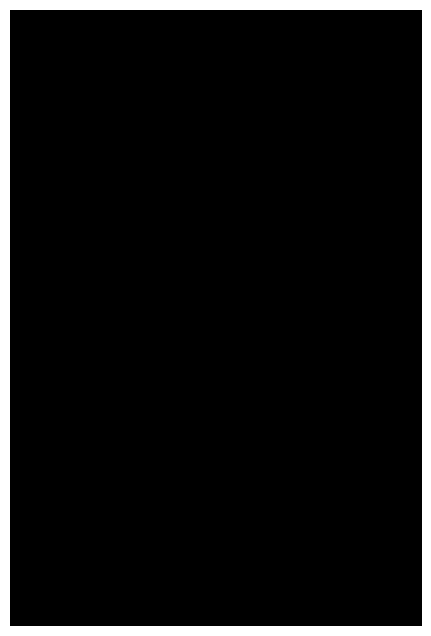

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


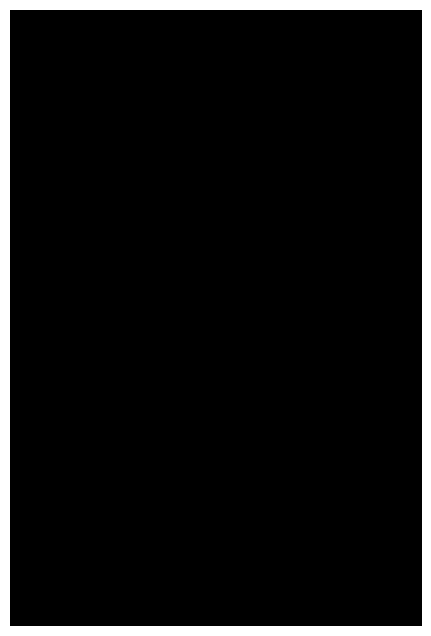

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


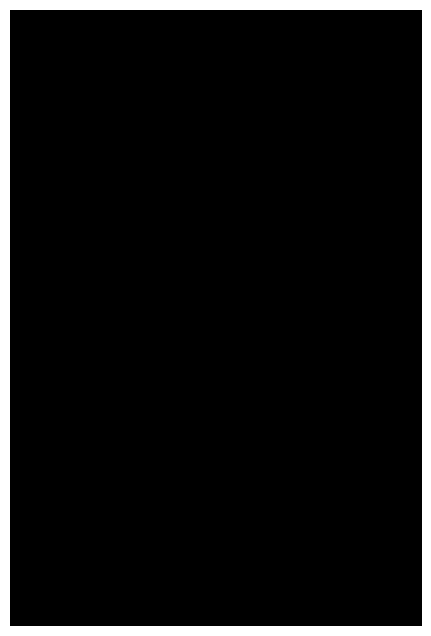

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


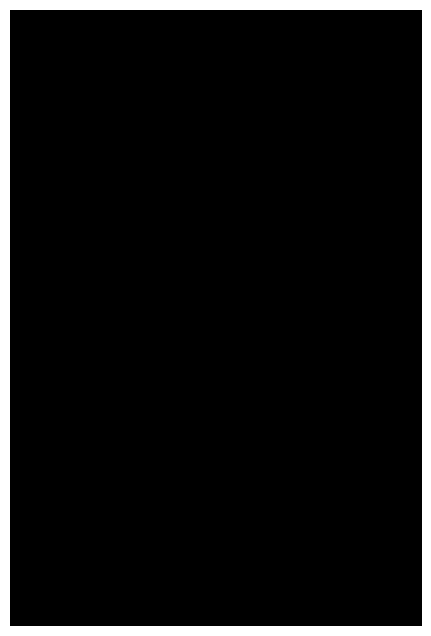

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


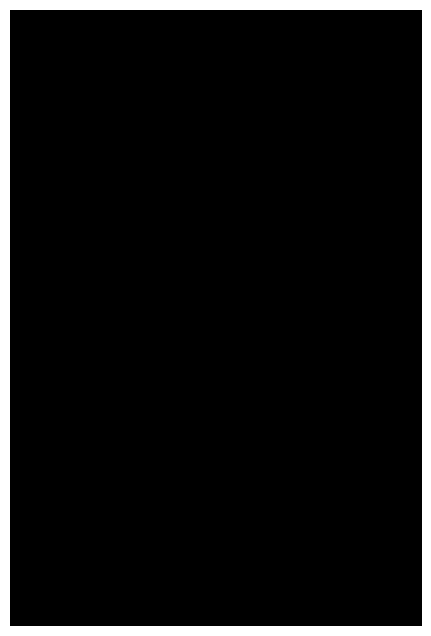

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


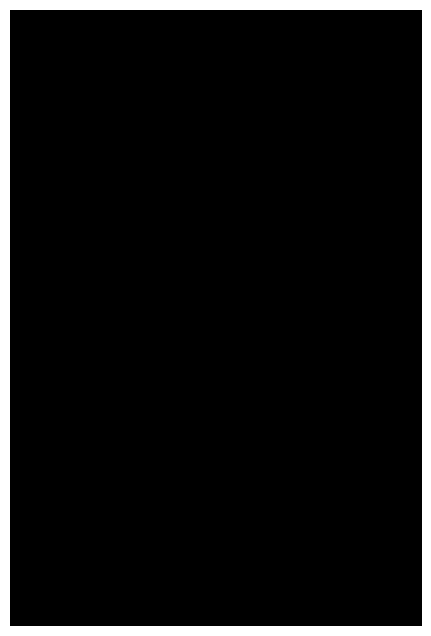

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


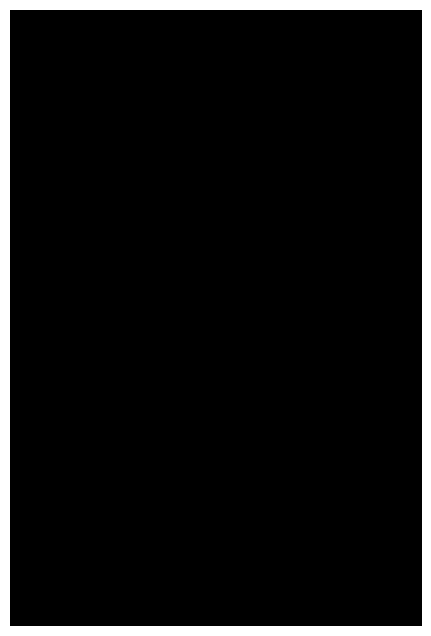

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


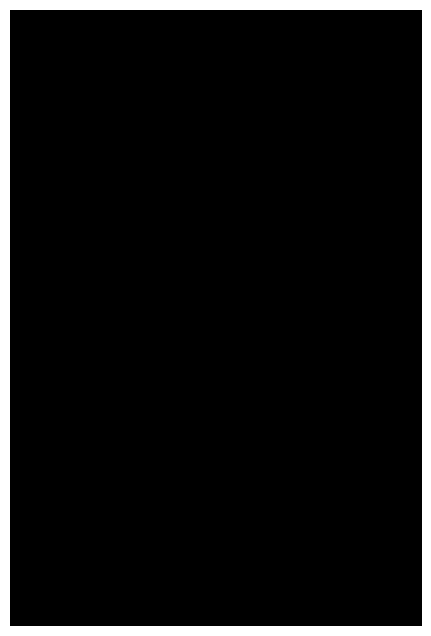

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


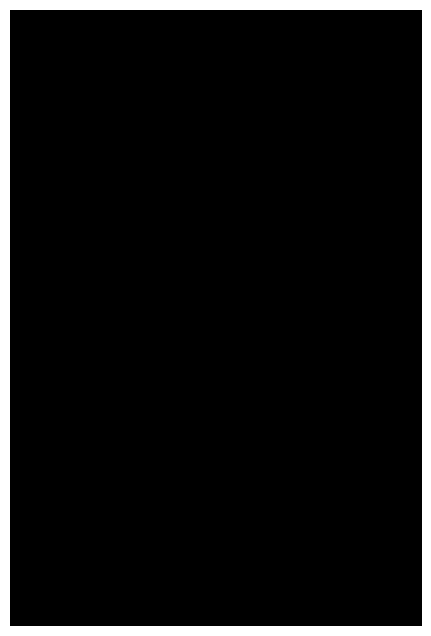

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


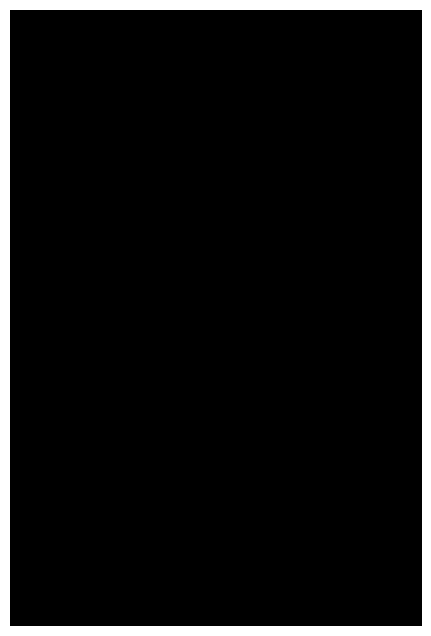

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


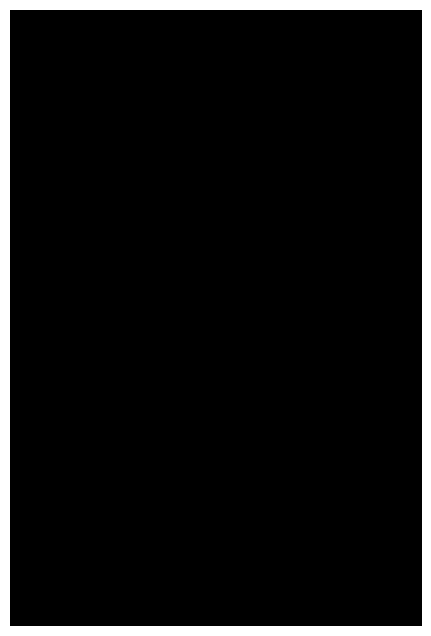

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


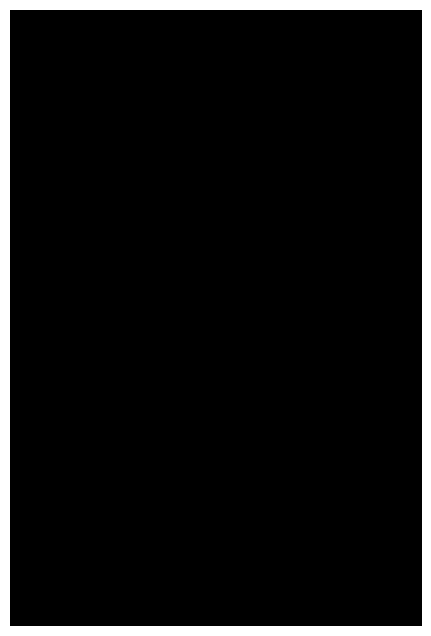

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


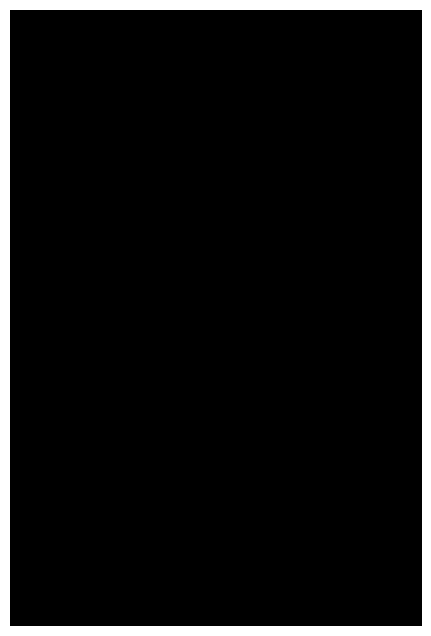

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


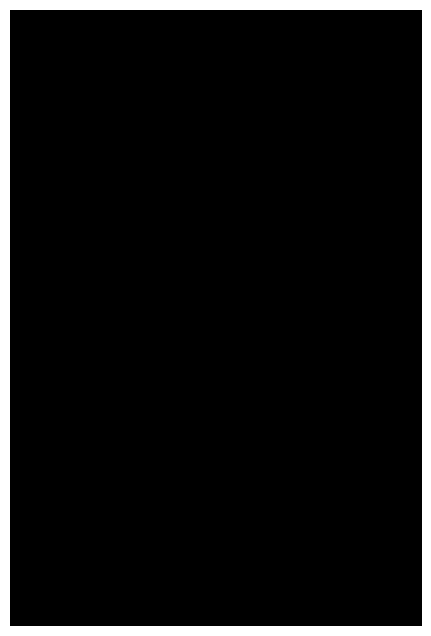

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


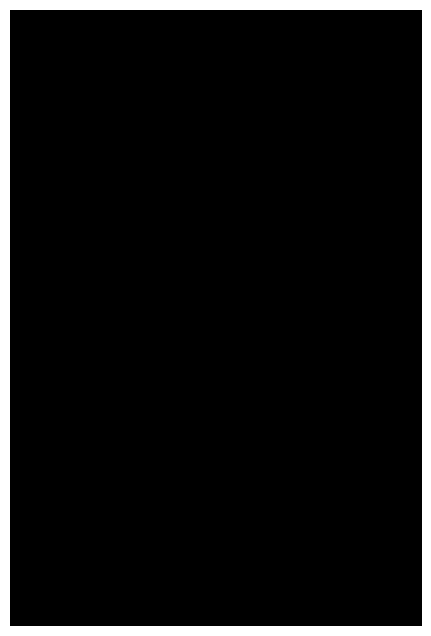

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


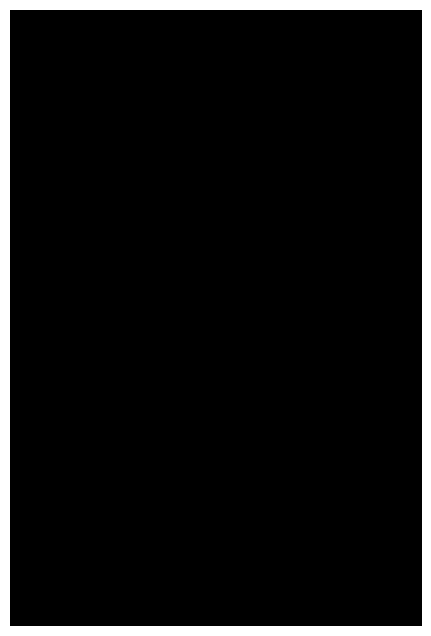

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


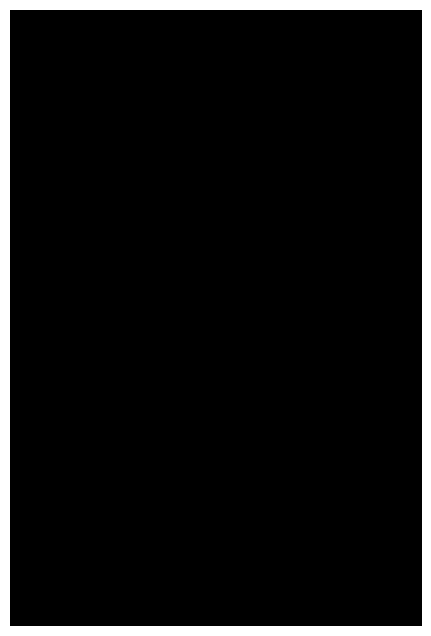

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


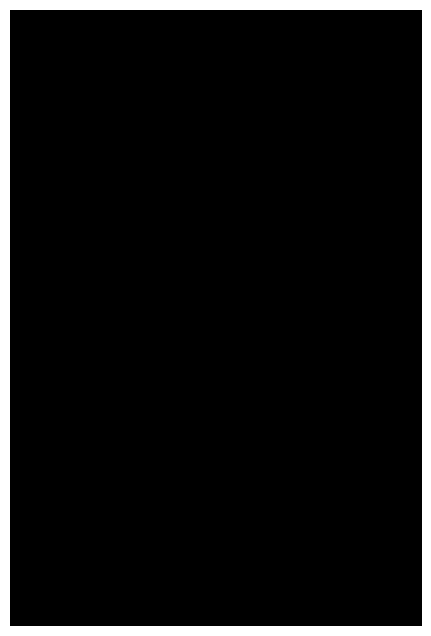

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


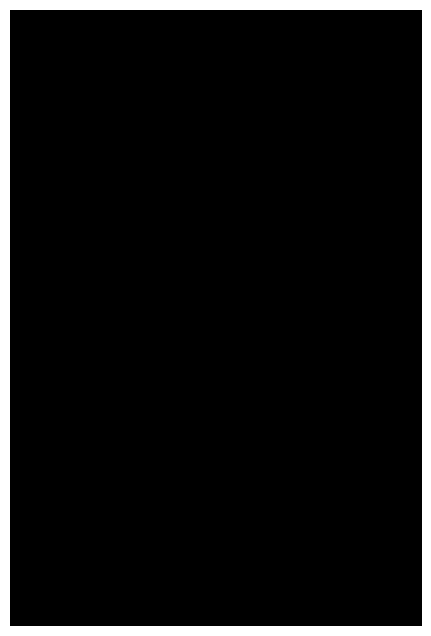

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


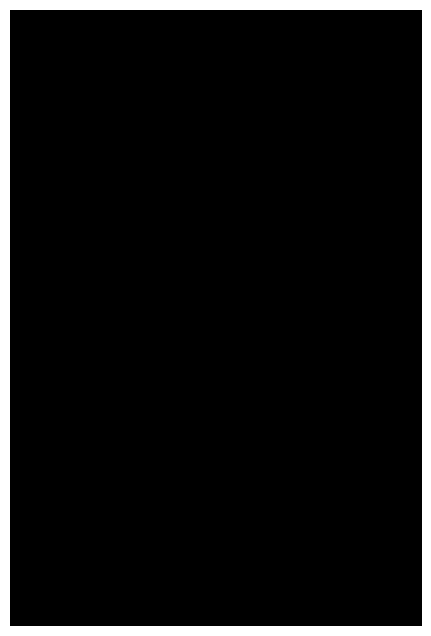

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


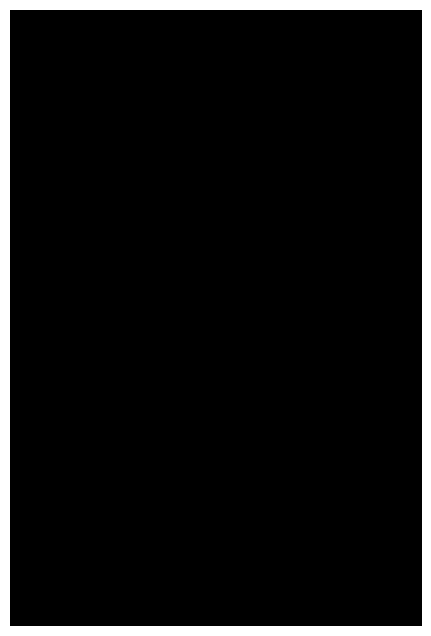

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


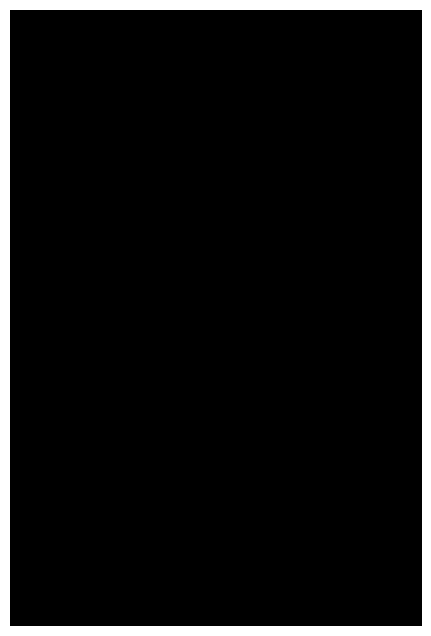

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


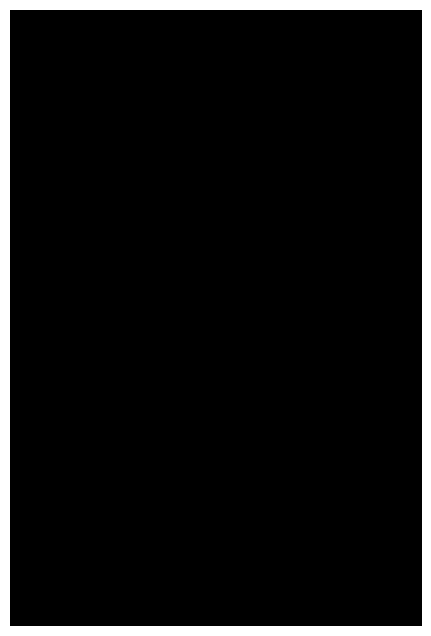

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


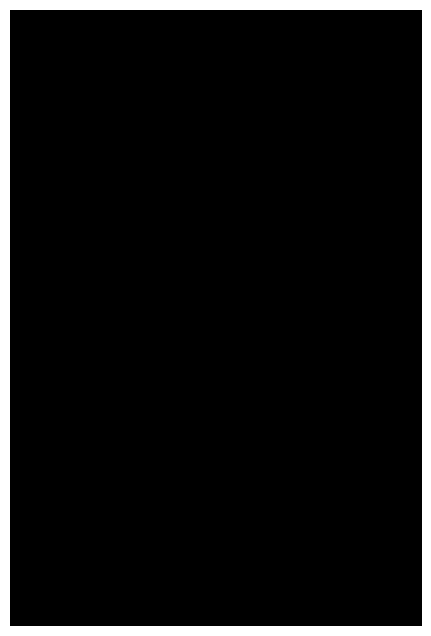

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


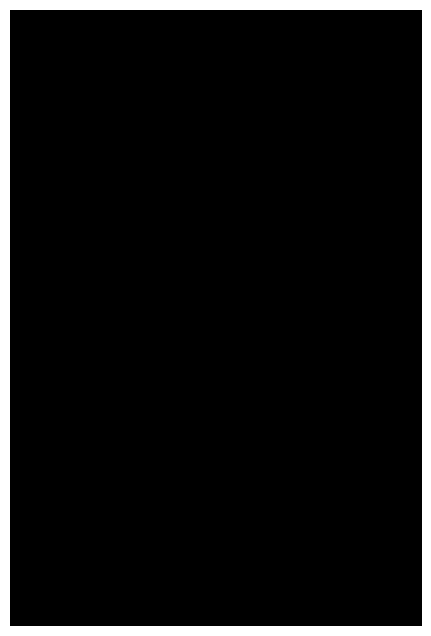

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


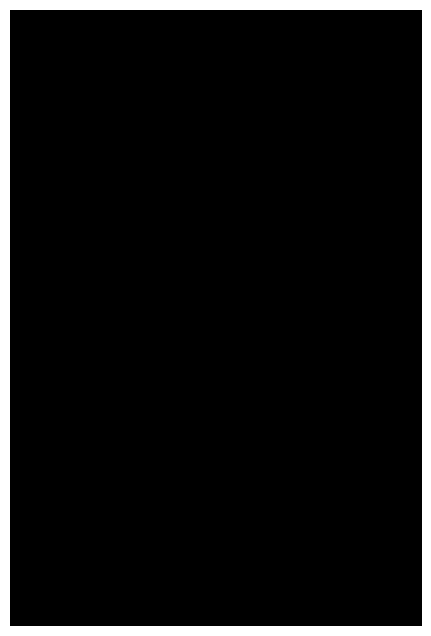

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


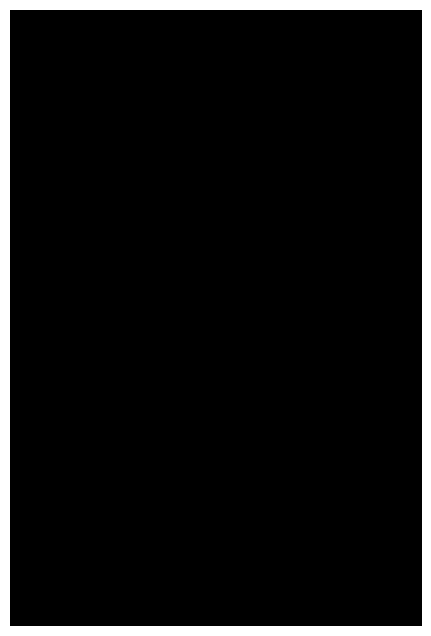

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


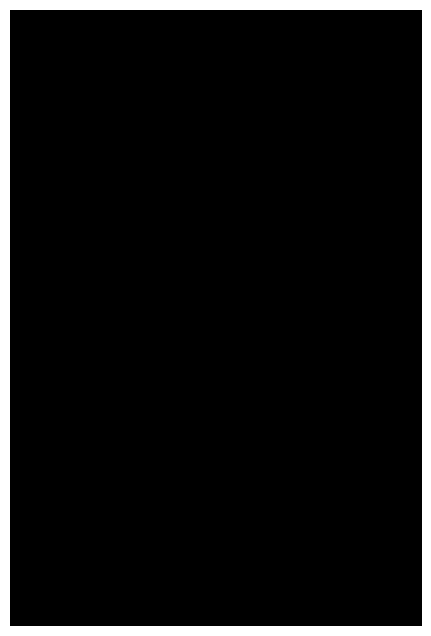

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


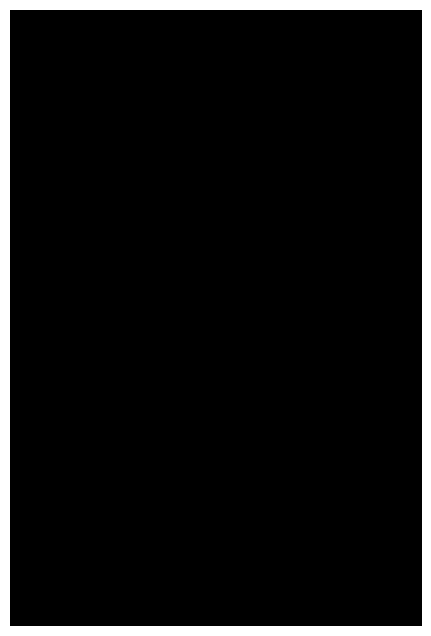

tensor([[[[nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          ...,
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj],
          [nan+nanj, nan+nanj, nan+nanj,  ..., nan+nanj, nan+nanj, nan+nanj]]]],
       device='cuda:0', dtype=torch.complex128)


KeyboardInterrupt: 

In [190]:
if __name__ == '__main__':
    ycbcr_mode = args.ycbcr == 'True'
    kernel_path = '/content/gdrive/MyDrive/HPPP/Prox_PnP/PnP_restoration/kernels/Levin09.mat'
    kernels = hdf5storage.loadmat(kernel_path)

    if not ycbcr_mode and 'set12' in args.dataset:
        test_path = './Prox_PnP/datasets/set12/'
        test_imgs = os.listdir(test_path)
    elif not ycbcr_mode and 'BSD68' in args.dataset:
        test_path = './Prox_PnP/datasets/BSD68_gray/'
        test_imgs = os.listdir(test_path)
    elif not ycbcr_mode and 'BSD8' in args.dataset:
        test_path = './datasets/BSD8/'
        test_imgs = os.listdir(test_path)
    else:
        test_imgs = ['bike','butterfly', 'flower', 'girl', 'hat', 'parrots',  'boats','house', 'leaves', 'starfish', 'cameraman', 'peppers']
    img_type = 'gray' if not ycbcr_mode else 'RGB'
    # print('img_type: ', img_type)
    task = args.task
    noise_level =args.noise_level
    algorithm = args.algo#'SAM_PROv2'
    print('ycbcr_mode: ', ycbcr_mode)
    print('algorithm: ', algorithm)
    print('task: ', task)
    print('noise_level: ', noise_level)
    if task == 'Uniform-deblurring': # Uniform blur
        k = (1/81)*np.ones((9,9))
        Sf = 1
    elif task == 'Gaussian-deblurring':  # Gaussian blur
        k = matlab_style_gauss2D(shape=(25,25),sigma=1.6)
        Sf = 1
    elif task == 'Super-resolution':  # Gaussian blur
        k = matlab_style_gauss2D(shape=(7,7),sigma=1.6)
        Sf = args.scale
        noise_level = 5
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    # we changed it! since we didn't find the model
    # model_type = 'FNE_DnCNN' #'RealSN_DnCNN'|'RealSN_SimpleCNN'
    model_type = 'RealSN_DnCNN' #'RealSN_SimpleCNN'

    sys.path.append(os.path.join(os.getcwd(), 'Provable_PnP'))
    f = load_model(model_type, 5, device)
    print ('##########################before#initialize#cuda#gray#denoiser')
    GS_model = initialize_cuda_gray_denoiser(device)
    print ('##########################after#initialize#cuda#gray#denoiser')
    total_PSNR = 0
    for name in test_imgs:
        if img_type == 'RGB':
            input_im_uint = imread_uint('test_images/'+name+'.tif',n_channels=3)
        #     input_im_uint = imread_uint('datasets/set12/05.png', n_channels=3)
        else:
            # input_im_uint = imread_uint('test_images/'+name+'.tif',n_channels=1)
            input_im_uint = imread_uint(test_path+name, n_channels=1) if not ycbcr_mode else imread_uint('test_images/'+name+'.tif',n_channels=1)
        #     input_im_uint = imread_uint('datasets/set12/05.png', n_channels=1)
        input_im = np.float32(input_im_uint / 255)
                    # Degrade image
        if Sf>1:#super-resolution
            blur_im = numpy_degradation(input_im, k, sf=Sf)
        else:# debluring
            blur_im = ndimage.filters.convolve(input_im, np.expand_dims(k, axis=2), mode='wrap')
        np.random.seed(seed=0)
        noise = np.random.normal(0, noise_level / 255., blur_im.shape)
        blur_im += noise
        prox_noise_norm = np.sqrt((noise_level / 255.)**2 * blur_im.shape[0] * blur_im.shape[1])
        print('noise norm: ', prox_noise_norm)
        init_im = blur_im
        x_gt = rgb2ycbcr(input_im_uint) if ycbcr_mode else input_im_uint[..., 0]
        if not ycbcr_mode:
            init_im1 = init_im#rgb2ycbcr(norm_proj(init_im))
            img_tensor = array2tensor(init_im1).to(device)
        else:
            init_im1 = rgb2ycbcr(norm_proj(init_im))
            init_im2 = np.expand_dims(init_im1, axis=2)
            img_tensor = array2tensor(init_im2).to(device)
        if img_type == 'RGB' and Sf==1:########ycbcr_mode
            degradation_mode = 'deblurring'
            x0 = img_tensor#初值
        elif Sf>1:########ycbcr_mode super-resolution
            degradation_mode = 'SR'
            x0 = cv2.resize(init_im1, (init_im1.shape[1] * Sf, init_im1.shape[0] * Sf),interpolation=cv2.INTER_CUBIC)
            x0 = np.expand_dims(x0, axis=2)
            x0 = utils_sr.shift_pixel(x0, Sf)
            x0 = array2tensor(x0).to(device)
        else:############gray
            degradation_mode = 'deblurring'
            x0 = img_tensor#初值

            img_tensor = array2tensor(init_im).to(device)
        FB, FBC, F2B, FBFy, k_tensor = initialize_prox(img_tensor, degradation_mode, k, Sf, device)

        ################################################algorithm setting####################################################################
        if noise_level<=5.0:
            sigma_f=5
        elif 15 >= noise_level>5:
            sigma_f=15
        elif 40 >= noise_level> 15:
            sigma_f=25
        else:
            print('error')
        ##################################################################################################################################
        print('algorithm : ', algorithm)
        with torch.no_grad():
            if algorithm == 'SAM_PROv1':###S(x) = x-s\nabla f(x)
                opt_r={'alpha':2, 'beta':0.1, 'sigma':noise_level, 'sigma_f':sigma_f, 'K':500, 'mu_0':500, 'sf': Sf}
                x1, objfun,r = SAM_PRO_v1(x0,img_tensor, k_tensor, degradation_mode, FB, FBC, FBFy, f, opt_r)
            elif algorithm == 'PnP_FBS':###S(x) = x-s\nabla f(x)
                opt_PnP_FBS={'alpha':2*noise_level, 'beta':0.1, 'sigma':noise_level, 'sigma_f':sigma_f, 'K':500, 'lambda':0.01,'input_sigma':noise_level**2, 'sf': Sf, 'gt':x_gt}
                x1, objfun, r,_ = PnP_FBS(x0,img_tensor, k_tensor, degradation_mode, FB, FBC, FBFy, f, opt_PnP_FBS)
            elif algorithm == 'SAM_PROv2':###S(x) = Tx-s\nabla f(Tx)
                if name == 'butterfly':
                    opt={'alpha':4, 'beta':0.1, 'sigma':noise_level, 'sigma_f':sigma_f, 'K':500, 'mu_0':1800, 'sf': Sf}
                else:
                    opt={'alpha':4, 'beta':0.1, 'sigma':noise_level, 'sigma_f':sigma_f, 'K':2000, 'mu_0':500, 'sf': Sf}
                x1, objfun,r = SAM_PRO_v2(x0,img_tensor, k_tensor, degradation_mode, FB, FBC, FBFy, f, opt)
            elif algorithm == 'RED':
                # opt_RED={'model_type': model_type,'alpha':2.4, 'beta':0.1, 'sigma':noise_level, 'sigma_f':sigma_f, 'K':2000, 'lambda':0.02,'input_sigma':noise_level**2, 'sf': Sf} #for butterfly
                opt_RED={'model_type': model_type,'alpha':2*noise_level, 'beta':0.1, 'sigma':noise_level, 'sigma_f':sigma_f, 'K':500, 'lambda':0.01,'input_sigma':noise_level**2, 'sf': Sf, 'gt':x_gt} #for parrots
                x1, objfun, r,_ = RED(x0,img_tensor, k_tensor, degradation_mode, FB, FBC, FBFy, f, opt_RED)
            elif algorithm == 'REDPRO':
                opt_REDPRO={'model_type': model_type,'alpha':2*noise_level, 'beta':0.1, 'sigma':noise_level, 'sigma_f':sigma_f, 'K':500, 'lambda':0.01,'input_sigma':noise_level**2, 'sf': Sf, 'gt':x_gt}
                x1, objfun, r,_ = REDPRO(x0,img_tensor, k_tensor, degradation_mode, FB, FBC, FBFy, f, opt_REDPRO)
            # we comment it to go on
            elif algorithm == 'CRED':
                opt_CRED={'model_type': model_type, 'model_name': 'dncnn', 'n_channels':1, 'alpha':1, 'beta':1, 'sigma':noise_level, 'sigma_norm':0.98*prox_noise_norm, 'sigma_f':sigma_f, 'K':200, 'mu_0':500, 'sf': Sf}
                x1, objfun = CRED_ADMM(x0,img_tensor, k_tensor, degradation_mode, FB, F2B, FBC, f, opt_CRED)
            # we put it away since there's a mismatch on projrction on L2 ball that we don't know how to solve (:
            elif algorithm == 'PLM':
                # opt_SCFP={'model_type': model_type, 'model_name': 'dncnn', 'n_channels':1, 'alpha':1, 'beta':0.1, 'sigma':noise_level, 'sigma_norm':prox_noise_norm-0.2, 'sigma_f':sigma_f, 'K':2000, 'mu_0':500, 'sf': Sf}
                opt_SCFP={'model_type': model_type, 'model_name': 'dncnn', 'n_channels':1, 'alpha':1, 'beta':0.1, 'sigma':noise_level, 'sigma_norm':prox_noise_norm-0.2, 'sigma_f':sigma_f, 'K':500, 'mu_0':500, 'sf': Sf, 'gt':x_gt}
                x1, objfun,_ =PLM(x0,img_tensor, k_tensor, degradation_mode, FB, FBC, f, opt_SCFP)
            elif algorithm == 'GraRED_HP3':
                opt_RED_HP3={'model_type': model_type, 'anchor_type': 'initialization', 'q':500, 'lambda_k':0.2, 'beta':1, 'tau':3, 's':1/3,'sigma':noise_level, 'lambda':40,'sigma_f':sigma_f, 'K':500, 'input_sigma':noise_level**2, 'sf': Sf}
                y0 = x0
                # xa = single2tensor4(PT(blur_im)).to(device)
                # ya = 0*xa
                xa = x0
                ya = y0
                x1, objfun, r = GraRED_HP3(x0, y0, xa, ya, img_tensor, k_tensor, degradation_mode, FB, FBC, F2B, FBFy, f, opt_RED_HP3)
            elif algorithm == 'GraRED_GS_HP3':
                #GraRED_GS_HP3参数：tau1.8,s1/.8,sigma_denoiser5,lambd30
                ###Restart_GraRED_GS_HP3参数：除了pepper设置:tau2.4,s1/2.4,sigma_denoiser5,lambd30;其他设置:tau1.8,s1/1.8,sigma_denoiser5,lambd30
                opt_RED_HP3={'model_type': model_type, 'anchor_type': 'restart', 'q':40, 'lambda_k':0.2, 'beta':1, 'tau':2.4, 's':1/2.4,'sigma':noise_level, 'sigma_denoiser':5,'lambda':30,'sigma_f':sigma_f, 'K':500, 'input_sigma':noise_level**2, 'sf': Sf}
                y0 = x0
                # xa = single2tensor4(PT(blur_im)).to(device)
                # ya = 0*xa
                xa = x0
                ya = y0
                x1, objfun, r = GraRED_GS_HP3(x0, y0, xa, ya, img_tensor, k_tensor, degradation_mode, FB, FBC, F2B, FBFy, GS_model, opt_RED_HP3, device)
            else:
                print('algorithm not implemented ^_^')
        if not ycbcr_mode:
            x_est = tensor2uint(x1)
            PSNR = calculate_psnr(x_gt, x_est)
        else:
            ###############################MATLAB PSNR, Follow RED paper################################
            import matlab
            import matlab.engine
            eng = matlab.engine.start_matlab()
            eng.addpath(eng.genpath(eng.fullfile(os.getcwd(),'Metrics')))
            x_gt_luma =x_gt
            im_ycbr = rgb2ycbcr(norm_proj(init_im), only_y=False)
            im_ycbr2 = rgb2ycbcr(norm_proj(init_im), only_y=False)
            x_est_luma = tensor2uint(x1)
            PSNR = eng.ComputePSNR(matlab.uint8(x_gt_luma.tolist()), matlab.uint8(x_est_luma.tolist()))###Followed by RED paper
        total_PSNR += PSNR
        print('{} - PSNR: {:.4f} dB'.format(name, PSNR))



    print('Average PSNR: {:.4f} dB'.format(total_PSNR / len(test_imgs)))
